### „Prognose von Benzinpreisen in Köln Aral“

1. Projektziel

Zwei Hauptfragen beantworten:

-  Preisentwicklung
Wie entwickeln sich die Benzinpreise im Zeitverlauf?
-  Beste Tankzeit
Wann ist der günstigste Zeitpunkt zum Tanken?

2. Projektstruktur
- ETL -> EDA -> ML -> Visualisierung

In [1]:
## 1. Bibliotheken importieren & Daten laden
import pandas as pd                                                                     # Pandas für Datenanalyse importieren
import numpy as np                                                                      # numpy für Datenanalyse importieren

# Zusätzliche Importe für erweiterte Transformationen
from sklearn.preprocessing import LabelEncoder, StandardScaler

## 2. Importiert das warnings-Modul
import warnings                                                                         # Dieses Modul wird verwendet, um Warnmeldungen von Python zu steuern
warnings.filterwarnings('ignore')                                                       # Unterdrückt (ignoriert) alle Warnmeldungen

## A. Extrarien, Transformieren und Laoden (ETL)


1. Vorbereitung und Reinigung für Preis

In [2]:
# 1. Daten laden und Überblick
df_preis = pd.read_parquet("spritpreisprognose/data/tankstellen_preise.parquet")  # von Felix in Githup

## 3. Erste Übersicht über die Daten
print (df_preis.shape)                                                                        # Anzahl Zeilen und Spalten anzeigen
display(df_preis.head(5))                                                                     # Erste 5 Zeilen anzeigen
df_preis.info()                                                                               # Spalten, Datentypen und Nullwerte anzeigen

(2430846, 5)


,date,station_uuid,diesel,e5,e10
0,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,1.339,1.539,1.499
1,2014-06-09 00:02:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,1.429,1.629,1.589
2,2014-06-09 02:38:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,1.389,1.589,1.549
3,2014-06-09 04:26:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,1.359,1.559,1.519
4,2014-06-09 05:54:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,1.339,1.539,1.499


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430846 entries, 0 to 2430845
Data columns (total 5 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   station_uuid  object        
 2   diesel        float32       
 3   e5            float32       
 4   e10           float32       
dtypes: datetime64[ns](1), float32(3), object(1)
memory usage: 64.9+ MB


In [3]:
# 2. Datentypen korrigieren
df_preis["diesel"] = pd.to_numeric(df_preis["diesel"], errors="coerce")             # ungültige Werte → NaN
df_preis["e5"] = pd.to_numeric(df_preis["e5"], errors="coerce")                     # gleiche Logik
df_preis["e10"] = pd.to_numeric(df_preis["e10"], errors="coerce")                   # gleiche Logik

In [4]:
# Datum in datetime umwandeln (sehr wichtig für Zeitanalyse)
# Datum in datetime umwandeln
df_preis["date"] = pd.to_datetime(df_preis["date"])

# station_uuid als String setzen
df_preis["station_uuid"] = df_preis["station_uuid"].astype(str)

In [5]:

#3. Ungültige Preiswerte bereinigen
# alle Kraftstoff-Spalten durchlaufen
for col in ["diesel", "e5", "e10"]:
    
    # in numerisch umwandeln (Fehler → NaN)
    df_preis[col] = pd.to_numeric(df_preis[col], errors="coerce")
    
    # unrealistische Werte entfernen (<0.5€ oder >3€)
    df_preis.loc[(df_preis[col] < 0.5) | (df_preis[col] > 3.0), col] = None

In [6]:
## Duplikate Zeigen / Prüfen
df_preis[df_preis.duplicated()]
print("\nAnzahl Duplikate vor Entfernung:", df_preis.duplicated().sum())



Anzahl Duplikate vor Entfernung: 0


In [7]:
# Duplikate Zeilen entfernen
df_preis = df_preis.drop_duplicates()  # Duplikate Zeilen entfernen

In [8]:
# Sortieren
df_preis = df_preis.sort_values("date")  # zeitlich sortieren

In [9]:
## Anzahle der Fehlende Werte pro Spalte Anzeigen
print("\nFehlende Werte pro Spalte:")       # Titel
print(df_preis.isnull().sum())                    # Anzahl fehlender Werte pro Spalte anzeigen


Fehlende Werte pro Spalte:
date                0
station_uuid        0
diesel            179
e5              66499
e10             73061
dtype: int64


In [10]:
## alles Zeile, Spalte mit Fehlende Werte anzeige
display(df_preis[df_preis[["diesel", "e5", "e10"]].isna().any(axis=1)])

,date,station_uuid,diesel,e5,e10
579635,2014-06-08 09:50:01,236b1bde-bf3b-42b5-b8f5-3020286881bc,1.319,NaN,NaN
1296689,2014-06-09 00:02:01,5ecf6179-72d0-4597-bfa6-b33cebcd191a,1.299,1.499,NaN
579636,2014-06-09 00:02:01,236b1bde-bf3b-42b5-b8f5-3020286881bc,1.379,NaN,NaN
1296690,2014-06-09 02:54:01,5ecf6179-72d0-4597-bfa6-b33cebcd191a,1.359,1.559,NaN
1296691,2014-06-09 03:34:01,5ecf6179-72d0-4597-bfa6-b33cebcd191a,1.349,1.549,NaN
...,...,...,...,...,...
641275,2025-01-14 10:46:23,236b1bde-bf3b-42b5-b8f5-3020286881bc,1.649,NaN,NaN
641276,2025-01-14 12:39:10,236b1bde-bf3b-42b5-b8f5-3020286881bc,1.699,NaN,NaN
641277,2025-01-14 13:32:59,236b1bde-bf3b-42b5-b8f5-3020286881bc,1.639,NaN,NaN
641278,2025-01-14 14:46:13,236b1bde-bf3b-42b5-b8f5-3020286881bc,1.679,NaN,NaN


In [11]:

# # 4. Fehlende Werte sinnvoll behandeln (je Tankstelle, nicht global)
# # Warum? Eine globale Interpolation würde Preise zwischen unterschiedlichen Tankstellen vermischen.
# # Deshalb interpolieren wir innerhalb jeder station_uuid separat.

# df_preis = df_preis.sort_values(["station_uuid", "date"]).copy()

# for col in ["diesel", "e5", "e10"]:
#     df_preis[col] = (
#         df_preis.groupby("station_uuid")[col]
#         .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
#     )

# Optional: Zeilen entfernen, bei denen trotzdem alle 3 Preise fehlen
# (z. B. wenn eine Station über längere Zeit gar keine Werte hatte)
df_preis = df_preis.dropna(subset=["diesel", "e5", "e10"], how="all")


In [12]:
## Anzahle der Fehlende Werte pro Spalte Anzeigen
print("\nFehlende Werte pro Spalte:")       # Titel
print(df_preis.isnull().sum())                    # Anzahl fehlender Werte pro Spalte anzeigen


Fehlende Werte pro Spalte:
date                0
station_uuid        0
diesel            107
e5              66427
e10             72989
dtype: int64


In [13]:
# import pandas as pd
# import numpy as np

# # --------------------------------------------------
# # 1) Daten sortieren
# # Wichtig: Für Interpolation muss die Zeitreihe je Tankstelle
# # in zeitlich richtiger Reihenfolge vorliegen.
# # --------------------------------------------------
# df_preis = df_preis.sort_values(["station_uuid", "date"]).copy()

# # Datum sicherheitshalber in datetime umwandeln
# df_preis["date"] = pd.to_datetime(df_preis["date"], errors="coerce")

# --------------------------------------------------
# 2) Interpolation je Tankstelle
# Warum?
# Preise sollen nur innerhalb derselben Tankstelle geschätzt werden.
# So vermischen wir keine unterschiedlichen Stationen.
# --------------------------------------------------
preis_spalten = ["diesel", "e5", "e10"]

for col in preis_spalten:
    df_preis[col] = (
        df_preis.groupby("station_uuid")[col]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )

# --------------------------------------------------
# 3) Fallback 1: Fehlende Werte mit Median je Tankstelle füllen
# Warum?
# Wenn eine Station z. B. bei E10 kaum Werte hat, kann Interpolation nicht helfen.
# Dann nehmen wir den typischen Preis dieser Station.
# --------------------------------------------------
for col in preis_spalten:
    df_preis[col] = (
        df_preis.groupby("station_uuid")[col]
        .transform(lambda s: s.fillna(s.median()))
    )

# --------------------------------------------------
# 4) Hilfsspalten aus Datum erzeugen
# Warum?
# Falls je Station noch immer etwas fehlt, können wir typische Preise
# eines Kalendertags oder Wochentags als sinnvollen Fallback nutzen.
# --------------------------------------------------
df_preis["jahr"] = df_preis["date"].dt.year
df_preis["monat"] = df_preis["date"].dt.month
df_preis["tag"] = df_preis["date"].dt.day
df_preis["wochentag"] = df_preis["date"].dt.weekday

# --------------------------------------------------
# 5) Fallback 2: Median je Datum
# Warum?
# Falls in einer Station fast alles fehlt, ist der Tagesmedian oft besser
# als ein globaler Gesamtwert.
# --------------------------------------------------
for col in preis_spalten:
    tagesmedian = df_preis.groupby("date")[col].transform("median")
    df_preis[col] = df_preis[col].fillna(tagesmedian)

# --------------------------------------------------
# 6) Fallback 3: Gesamtmedian
# Warum?
# Das ist die letzte Sicherheitsstufe, damit wirklich keine NaN übrig bleiben.
# --------------------------------------------------
for col in preis_spalten:
    df_preis[col] = df_preis[col].fillna(df_preis[col].median())

# --------------------------------------------------
# 7) Kontrolle: Wie viele fehlende Werte gibt es noch?
# --------------------------------------------------
print("Fehlende Werte nach Bereinigung:")
print(df_preis[preis_spalten].isna().sum())

# --------------------------------------------------
# 8) Optional: Zeilen löschen, falls wirklich noch alles leer wäre
# --------------------------------------------------
df_preis = df_preis.dropna(subset=preis_spalten, how="all")

print("\nVerbleibende Datenform:", df_preis.shape)

Fehlende Werte nach Bereinigung:
diesel    0
e5        0
e10       0
dtype: int64

Verbleibende Datenform: (2430774, 9)


In [14]:
# 2. Datentypen korrigieren
df_preis["diesel"] = pd.to_numeric(df_preis["diesel"], errors="coerce")             # ungültige Werte → NaN
df_preis["e5"] = pd.to_numeric(df_preis["e5"], errors="coerce")                     # gleiche Logik
df_preis["e10"] = pd.to_numeric(df_preis["e10"], errors="coerce")                   # gleiche Logik

In [15]:
# 5. Wide → Long Format umwandeln (SEHR WICHTIG)
# Normalisierung

# Daten in langes Format bringen
df_preis_long = df_preis.melt(
    id_vars=["date", "station_uuid"],   # bleiben gleich
    value_vars=["diesel", "e5", "e10"], # werden transformiert
    var_name="kraftstoff",              # neue Spalte
    value_name="preis"                  # Preis
)

In [16]:
# 7. Zeit-Features erstellen

# Zeitinformationen extrahieren
df_preis_long["jahr"] = df_preis_long["date"].dt.year
df_preis_long["monat"] = df_preis_long["date"].dt.month
df_preis_long["tag"] = df_preis_long["date"].dt.day
df_preis_long["stunde"] = df_preis_long["date"].dt.hour
df_preis_long["minute"] = df_preis_long["date"].dt.minute
df_preis_long["sekunde"] = df_preis_long["date"].dt.second

# Wochentag (0=Montag)
df_preis_long["wochentag"] = df_preis_long["date"].dt.weekday

# Wochenende erkennen
df_preis_long["ist_wochenende"] = df_preis_long["wochentag"].isin([5, 6])

In [17]:
# ## Duplikate Zeigen / Prüfen
# df_preis_long[df_preis_long.duplicated()]

# print("\nAnzahl Duplikate vor Entfernung:", df_preis_long.duplicated().sum())

In [18]:
#8. Duplikate entfernen

# doppelte Einträge löschen
df_preis_long = df_preis_long.drop_duplicates(
    subset=["station_uuid", "date", "kraftstoff"]
)

In [19]:
# 9. Feature Engineering (Optional, aber sehr gut)

# Tageszeit einteilen
df_preis_long["tageszeit"] = pd.cut(
    df_preis_long["stunde"],
    bins=[0, 6, 12, 18, 24],
    labels=["nacht", "morgen", "mittag", "abend"],
    right=False
)

# # Preisänderung berechnen
# df_preis_long["preis_diff"] = df_preis_long.groupby(
#     ["station_uuid", "kraftstoff"]
# )["preis"].diff()



In [20]:
# Preisänderung berechnen
df_preis_long["preis_diff"] = (
    df_preis_long
    .groupby(["station_uuid", "kraftstoff"])["preis"]
    .diff()
)

# Erste Werte auf 0 setzen
df_preis_long["preis_diff"] = df_preis_long["preis_diff"].fillna(0)

# Extreme unplausible Preisänderungen optional auf NaN setzen
df_preis_long.loc[df_preis_long["preis_diff"].abs() > 0.5, "preis_diff"] = pd.NA

# Danach wieder sinnvoll füllen
df_preis_long["preis_diff"] = df_preis_long["preis_diff"].fillna(0)

In [21]:
display(df_preis_long)

,date,station_uuid,kraftstoff,preis,jahr,monat,tag,stunde,minute,sekunde,wochentag,ist_wochenende,tageszeit,preis_diff
0,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,diesel,1.339,2014,6,8,9,50,1,6,True,morgen,0.00
1,2014-06-08 09:50:01,d8c0829a-a543-4db9-b45c-387b6ab73cf3,diesel,1.389,2014,6,8,9,50,1,6,True,morgen,0.00
2,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-a51b92434d41,diesel,1.319,2014,6,8,9,50,1,6,True,morgen,0.00
3,2014-06-08 09:50:01,865baef1-d5b7-4fa0-b11d-ddcd803eb401,diesel,1.359,2014,6,8,9,50,1,6,True,morgen,0.00
4,2014-06-08 09:50:01,84920d2d-c673-498d-8b75-853fb47aab05,diesel,1.369,2014,6,8,9,50,1,6,True,morgen,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7292317,2026-03-19 23:12:50,51d4b453-a095-1aa0-e100-80009459e03a,e10,2.019,2026,3,19,23,12,50,3,False,abend,0.02
7292318,2026-03-19 23:12:50,51d4b50e-a095-1aa0-e100-80009459e03a,e10,2.029,2026,3,19,23,12,50,3,False,abend,0.02
7292319,2026-03-19 23:15:53,494c4782-ea6e-49bc-90c3-e64dd38b005a,e10,2.028,2026,3,19,23,15,53,3,False,abend,0.02
7292320,2026-03-19 23:17:55,005056ba-7cb6-1ed2-bceb-a51b92434d41,e10,2.049,2026,3,19,23,17,55,3,False,abend,0.04


In [22]:
## Anzahle der Fehlende Werte pro Spalte Anzeigen
print("\nFehlende Werte pro Spalte:")       # Titel
print(df_preis_long.isnull().sum())                    # Anzahl fehlender Werte pro Spalte anzeigen


Fehlende Werte pro Spalte:
date              0
station_uuid      0
kraftstoff        0
preis             0
jahr              0
monat             0
tag               0
stunde            0
minute            0
sekunde           0
wochentag         0
ist_wochenende    0
tageszeit         0
preis_diff        0
dtype: int64


In [23]:
# Datentyp ist
print("Datentyp :")
print(df_preis_long.dtypes)


Datentyp :
date              datetime64[ns]
station_uuid              object
kraftstoff                object
preis                    float32
jahr                       int32
monat                      int32
tag                        int32
stunde                     int32
minute                     int32
sekunde                    int32
wochentag                  int32
ist_wochenende              bool
tageszeit               category
preis_diff               float32
dtype: object


In [24]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_preis_long.dtypes)

# Umwandlung der Spalte 'object' in Datetime
# df_preis_long['datum'] = pd.to_datetime(df_preis_long['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_preis_long = df_preis_long[(df_preis_long['date'] >= '2015-01-01')]

df_preis_long = filtered_df_preis_long

print("-------------Nacher--------------------:")
print(df_preis_long.dtypes)
print("\n", df_preis_long)
display(df_preis_long)

Vorher:
date              datetime64[ns]
station_uuid              object
kraftstoff                object
preis                    float32
jahr                       int32
monat                      int32
tag                        int32
stunde                     int32
minute                     int32
sekunde                    int32
wochentag                  int32
ist_wochenende              bool
tageszeit               category
preis_diff               float32
dtype: object
-------------Nacher--------------------:
date              datetime64[ns]
station_uuid              object
kraftstoff                object
preis                    float32
jahr                       int32
monat                      int32
tag                        int32
stunde                     int32
minute                     int32
sekunde                    int32
wochentag                  int32
ist_wochenende              bool
tageszeit               category
preis_diff               float32
dtype: object

,date,station_uuid,kraftstoff,preis,jahr,monat,tag,stunde,minute,sekunde,wochentag,ist_wochenende,tageszeit,preis_diff
29123,2015-01-01 05:06:01,6d5c8108-b7bd-4213-9685-b0c132da2d9d,diesel,1.209,2015,1,1,5,6,1,3,False,nacht,-0.04
29124,2015-01-01 05:06:01,62a2fdf4-602e-4e49-b398-c7242da31987,diesel,1.219,2015,1,1,5,6,1,3,False,nacht,-0.02
29125,2015-01-01 05:06:01,865baef1-d5b7-4fa0-b11d-ddcd803eb401,diesel,1.209,2015,1,1,5,6,1,3,False,nacht,-0.04
29126,2015-01-01 05:06:01,84920d2d-c673-498d-8b75-853fb47aab05,diesel,1.219,2015,1,1,5,6,1,3,False,nacht,-0.02
29127,2015-01-01 05:14:01,833c5106-cf84-4da5-b427-71839081b391,diesel,1.179,2015,1,1,5,14,1,3,False,nacht,-0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7292317,2026-03-19 23:12:50,51d4b453-a095-1aa0-e100-80009459e03a,e10,2.019,2026,3,19,23,12,50,3,False,abend,0.02
7292318,2026-03-19 23:12:50,51d4b50e-a095-1aa0-e100-80009459e03a,e10,2.029,2026,3,19,23,12,50,3,False,abend,0.02
7292319,2026-03-19 23:15:53,494c4782-ea6e-49bc-90c3-e64dd38b005a,e10,2.028,2026,3,19,23,15,53,3,False,abend,0.02
7292320,2026-03-19 23:17:55,005056ba-7cb6-1ed2-bceb-a51b92434d41,e10,2.049,2026,3,19,23,17,55,3,False,abend,0.04


In [25]:
# nur relevante Spalten behalten
df_preis_long_db = df_preis_long[[
    "date",
    "station_uuid",
    "kraftstoff",
    "preis"
]]

In [26]:
# 10. Bereinigte Daten speichern

# bereinigte Datei speichern
df_preis_long_db.to_parquet("clean_preise.parquet", index=False)

### 2. Vorbereitung von Datei Station

In [27]:
# 1. Daten laden und Überblick
import pandas as pd  # Datenverarbeitung

# Datei laden
df_stations = pd.read_parquet("spritpreisprognose/data/tankstellen_stationen.parquet")

# Überblick
display(df_stations.info())   # Datentypen prüfen
display(df_stations.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uuid          30 non-null     object 
 1   name          30 non-null     object 
 2   brand         29 non-null     object 
 3   street        30 non-null     object 
 4   house_number  22 non-null     object 
 5   post_code     30 non-null     object 
 6   city          30 non-null     object 
 7   latitude      30 non-null     float64
 8   longitude     30 non-null     float64
 9   distanz_km    30 non-null     float64
 10  stadt         30 non-null     object 
dtypes: float64(3), object(8)
memory usage: 2.7+ KB


None

,uuid,name,brand,street,house_number,post_code,city,latitude,longitude,distanz_km,stadt
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,star Tankstelle,STAR,Krankenhausstraße,98,50354,Hürth,50.888160,6.890150,4.370029,koeln
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,star Tankstelle,STAR,Koelner Straße,79,50226,Frechen,50.913260,6.827860,1.871092,koeln
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,AVEX Bachem,AVEX,Gleueler Str.,19,50226,Frechen,50.897400,6.821030,3.311539,koeln
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,Köln,50.925050,6.895290,3.052828,koeln
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"KOELN, BRAUWEILER STR.",Shell,BRAUWEILER STR. 30-32,None,50859,KOELN,50.945293,6.831367,3.228197,koeln


In [28]:
#2. Spalten bereinigen und umbenennen

#Ziel: konsistente Namen für Datenbank

# Spaltennamen vereinheitlichen (klein + ohne Leerzeichen)
df_stations.columns = df_stations.columns.str.lower().str.strip()

# optional: 'city' und 'stadt' vereinheitlichen
df_stations["stadt"] = df_stations["stadt"].fillna(df_stations["city"])
df_stations = df_stations.drop(columns=["city"], errors="ignore")

In [29]:
display(df_stations)

,uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,star Tankstelle,STAR,Krankenhausstraße,98,50354,50.888160,6.890150,4.370029,koeln
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,star Tankstelle,STAR,Koelner Straße,79,50226,50.913260,6.827860,1.871092,koeln
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,AVEX Bachem,AVEX,Gleueler Str.,19,50226,50.897400,6.821030,3.311539,koeln
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,50.925050,6.895290,3.052828,koeln
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"KOELN, BRAUWEILER STR.",Shell,BRAUWEILER STR. 30-32,None,50859,50.945293,6.831367,3.228197,koeln
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,AVEX Frechen Tankautomat,AVEX,Bonnstr.,17,50226,50.911200,6.830140,1.828636,koeln
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,Armin Hess,Westfalen Tankstelle,Kölner Str.,111,50859,50.947310,6.843930,3.147741,koeln
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,Globus Handelshof GmbH & Co. KG Betriebsstaet...,Globus SB Warenhaus,Max-Planck Straße,9,50858,50.921450,6.853320,0.218239,koeln
8,51d4b453-a095-1aa0-e100-80009459e03a,JET HUERTH LUXEMBURGER STR. 259,JET,LUXEMBURGER STR. 259,None,50354,50.883400,6.894410,4.973213,koeln
9,51d4b50e-a095-1aa0-e100-80009459e03a,JET KOELN WIDDERSDORFER STR. 165,JET,WIDDERSDORFER STR. 165,None,50825,50.945000,6.907660,4.784574,koeln


In [30]:
# Liste aller Textspalten, die bereinigt werden sollen
text_cols = [
"name",
"brand",
"street",
"house_number",
"post_code",
"stadt"
]

# Funktion zur Bereinigung
def clean_text(col):
    return (
    col.astype(str) # alles zu String
    .str.strip() # Leerzeichen vorne/hinten entfernen
    .str.replace(r"\s+", " ", regex=True) # doppelte Leerzeichen entfernen
    .str.title() # Einheitliche Schreibweise (Köln, Aral)
)

# Anwenden auf alle Spalten
for col in text_cols:
    if col in df_stations.columns:
        df_stations[col] = clean_text(df_stations[col])

print("Textfelder bereinigt.")
display(df_stations)

Textfelder bereinigt.


,uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,Star Tankstelle,Star,Krankenhausstraße,98,50354,50.888160,6.890150,4.370029,Koeln
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,Star Tankstelle,Star,Koelner Straße,79,50226,50.913260,6.827860,1.871092,Koeln
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,Avex Bachem,Avex,Gleueler Str.,19,50226,50.897400,6.821030,3.311539,Koeln
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,50.925050,6.895290,3.052828,Koeln
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"Koeln, Brauweiler Str.",Shell,Brauweiler Str. 30-32,None,50859,50.945293,6.831367,3.228197,Koeln
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,Avex Frechen Tankautomat,Avex,Bonnstr.,17,50226,50.911200,6.830140,1.828636,Koeln
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,Armin Hess,Westfalen Tankstelle,Kölner Str.,111,50859,50.947310,6.843930,3.147741,Koeln
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,Globus Handelshof Gmbh & Co. Kg Betriebsstaett...,Globus Sb Warenhaus,Max-Planck Straße,9,50858,50.921450,6.853320,0.218239,Koeln
8,51d4b453-a095-1aa0-e100-80009459e03a,Jet Huerth Luxemburger Str. 259,Jet,Luxemburger Str. 259,None,50354,50.883400,6.894410,4.973213,Koeln
9,51d4b50e-a095-1aa0-e100-80009459e03a,Jet Koeln Widdersdorfer Str. 165,Jet,Widdersdorfer Str. 165,None,50825,50.945000,6.907660,4.784574,Koeln


In [31]:
# 3. Datentypen korrigieren
# String-Spalten bereinigen
for col in ["street", "house_number", "post_code", "stadt"]:
    df_stations[col] = df_stations[col].astype(str).str.strip()

# numerische Spalten korrekt setzen
df_stations["latitude"] = pd.to_numeric(df_stations["latitude"], errors="coerce")
df_stations["longitude"] = pd.to_numeric(df_stations["longitude"], errors="coerce")
df_stations["distanz_km"] = pd.to_numeric(df_stations["distanz_km"], errors="coerce")

In [32]:
#4. Geodaten validieren

#Koordinaten müssen gültig sein

# ungültige Koordinaten entfernen
df_stations = df_stations[
    (df_stations["latitude"].between(-90, 90)) &
    (df_stations["longitude"].between(-180, 180))
]

In [33]:
#5. Fehlende Werte behandeln
# Zeilen ohne wichtige Standortdaten entfernen
df_stations = df_stations.dropna(subset=["street", "post_code", "stadt"])

# fehlende Hausnummern optional ersetzen
df_stations["house_number"] = df_stations["house_number"].replace("nan", None)

In [34]:
## Duplikate Zeigen / Prüfen
df_stations[df_stations.duplicated()]

print("\nAnzahl Duplikate vor Entfernung:", df_stations.duplicated().sum())


Anzahl Duplikate vor Entfernung: 0


In [35]:
#6. Duplikate entfernen

#gleiche Adresse = gleiche Tankstelle (falls keine UUID vorhanden)

df_stations = df_stations.drop_duplicates(
    subset=["street", "house_number", "post_code", "stadt"]
)

In [36]:
display(df_stations)

,uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,Star Tankstelle,Star,Krankenhausstraße,98,50354,50.888160,6.890150,4.370029,Koeln
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,Star Tankstelle,Star,Koelner Straße,79,50226,50.913260,6.827860,1.871092,Koeln
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,Avex Bachem,Avex,Gleueler Str.,19,50226,50.897400,6.821030,3.311539,Koeln
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,50.925050,6.895290,3.052828,Koeln
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"Koeln, Brauweiler Str.",Shell,Brauweiler Str. 30-32,None,50859,50.945293,6.831367,3.228197,Koeln
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,Avex Frechen Tankautomat,Avex,Bonnstr.,17,50226,50.911200,6.830140,1.828636,Koeln
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,Armin Hess,Westfalen Tankstelle,Kölner Str.,111,50859,50.947310,6.843930,3.147741,Koeln
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,Globus Handelshof Gmbh & Co. Kg Betriebsstaett...,Globus Sb Warenhaus,Max-Planck Straße,9,50858,50.921450,6.853320,0.218239,Koeln
8,51d4b453-a095-1aa0-e100-80009459e03a,Jet Huerth Luxemburger Str. 259,Jet,Luxemburger Str. 259,None,50354,50.883400,6.894410,4.973213,Koeln
9,51d4b50e-a095-1aa0-e100-80009459e03a,Jet Koeln Widdersdorfer Str. 165,Jet,Widdersdorfer Str. 165,None,50825,50.945000,6.907660,4.784574,Koeln


In [37]:
#7. Feature Engineering (optional)
# Entfernung runden (optional)
df_stations["distanz_km"] = df_stations["distanz_km"].round(2)

# Region / PLZ-Bereich extrahieren
df_stations["plz_region"] = df_stations["post_code"].str[:2]

display(df_stations)

,uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt,plz_region
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,Star Tankstelle,Star,Krankenhausstraße,98,50354,50.888160,6.890150,4.37,Koeln,50
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,Star Tankstelle,Star,Koelner Straße,79,50226,50.913260,6.827860,1.87,Koeln,50
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,Avex Bachem,Avex,Gleueler Str.,19,50226,50.897400,6.821030,3.31,Koeln,50
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,50.925050,6.895290,3.05,Koeln,50
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"Koeln, Brauweiler Str.",Shell,Brauweiler Str. 30-32,None,50859,50.945293,6.831367,3.23,Koeln,50
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,Avex Frechen Tankautomat,Avex,Bonnstr.,17,50226,50.911200,6.830140,1.83,Koeln,50
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,Armin Hess,Westfalen Tankstelle,Kölner Str.,111,50859,50.947310,6.843930,3.15,Koeln,50
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,Globus Handelshof Gmbh & Co. Kg Betriebsstaett...,Globus Sb Warenhaus,Max-Planck Straße,9,50858,50.921450,6.853320,0.22,Koeln,50
8,51d4b453-a095-1aa0-e100-80009459e03a,Jet Huerth Luxemburger Str. 259,Jet,Luxemburger Str. 259,None,50354,50.883400,6.894410,4.97,Koeln,50
9,51d4b50e-a095-1aa0-e100-80009459e03a,Jet Koeln Widdersdorfer Str. 165,Jet,Widdersdorfer Str. 165,None,50825,50.945000,6.907660,4.78,Koeln,50


In [38]:
#8. IDs vorbereiten für Datenbank

#wichtig für deine Tabellen: stadt, tankstelle

# eindeutige Städte extrahieren
df_stadt = df_stations[["stadt"]].drop_duplicates().reset_index(drop=True)

# ID vergeben
df_stadt["stadt_id"] = df_stadt.index + 1

# zurück mergen (für FK)
df_stations = df_stations.merge(df_stadt, on="stadt", how="left")

display(df_stadt)
display(df_stations)

,stadt,stadt_id
0,Koeln,1


,uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt,plz_region,stadt_id
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,Star Tankstelle,Star,Krankenhausstraße,98,50354,50.888160,6.890150,4.37,Koeln,50,1
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,Star Tankstelle,Star,Koelner Straße,79,50226,50.913260,6.827860,1.87,Koeln,50,1
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,Avex Bachem,Avex,Gleueler Str.,19,50226,50.897400,6.821030,3.31,Koeln,50,1
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,50.925050,6.895290,3.05,Koeln,50,1
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"Koeln, Brauweiler Str.",Shell,Brauweiler Str. 30-32,None,50859,50.945293,6.831367,3.23,Koeln,50,1
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,Avex Frechen Tankautomat,Avex,Bonnstr.,17,50226,50.911200,6.830140,1.83,Koeln,50,1
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,Armin Hess,Westfalen Tankstelle,Kölner Str.,111,50859,50.947310,6.843930,3.15,Koeln,50,1
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,Globus Handelshof Gmbh & Co. Kg Betriebsstaett...,Globus Sb Warenhaus,Max-Planck Straße,9,50858,50.921450,6.853320,0.22,Koeln,50,1
8,51d4b453-a095-1aa0-e100-80009459e03a,Jet Huerth Luxemburger Str. 259,Jet,Luxemburger Str. 259,None,50354,50.883400,6.894410,4.97,Koeln,50,1
9,51d4b50e-a095-1aa0-e100-80009459e03a,Jet Koeln Widdersdorfer Str. 165,Jet,Widdersdorfer Str. 165,None,50825,50.945000,6.907660,4.78,Koeln,50,1


In [39]:
df_stations.nunique()

uuid            30
name            21
brand           14
street          27
house_number    21
post_code        7
latitude        28
longitude       29
distanz_km      29
stadt            1
plz_region       1
stadt_id         1
dtype: int64

In [40]:
#9. (Optional) station_uuid hinzufügen

# # Falls in dieser Datei keine UUID existiert

# import uuid  # für eindeutige IDs

# # neue UUID generieren
# df_stations["station_uuid"] = [str(uuid.uuid4()) for _ in range(len(df_stations))]


df_stations.rename(columns={"uuid": "station_uuid"}, inplace=True)

display(df_stations)

,station_uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt,plz_region,stadt_id
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,Star Tankstelle,Star,Krankenhausstraße,98,50354,50.888160,6.890150,4.37,Koeln,50,1
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,Star Tankstelle,Star,Koelner Straße,79,50226,50.913260,6.827860,1.87,Koeln,50,1
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,Avex Bachem,Avex,Gleueler Str.,19,50226,50.897400,6.821030,3.31,Koeln,50,1
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,50.925050,6.895290,3.05,Koeln,50,1
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"Koeln, Brauweiler Str.",Shell,Brauweiler Str. 30-32,None,50859,50.945293,6.831367,3.23,Koeln,50,1
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,Avex Frechen Tankautomat,Avex,Bonnstr.,17,50226,50.911200,6.830140,1.83,Koeln,50,1
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,Armin Hess,Westfalen Tankstelle,Kölner Str.,111,50859,50.947310,6.843930,3.15,Koeln,50,1
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,Globus Handelshof Gmbh & Co. Kg Betriebsstaett...,Globus Sb Warenhaus,Max-Planck Straße,9,50858,50.921450,6.853320,0.22,Koeln,50,1
8,51d4b453-a095-1aa0-e100-80009459e03a,Jet Huerth Luxemburger Str. 259,Jet,Luxemburger Str. 259,None,50354,50.883400,6.894410,4.97,Koeln,50,1
9,51d4b50e-a095-1aa0-e100-80009459e03a,Jet Koeln Widdersdorfer Str. 165,Jet,Widdersdorfer Str. 165,None,50825,50.945000,6.907660,4.78,Koeln,50,1


In [41]:
def extract_house_number_regex(df, street_col="street", house_col="house_number"):
    # Create a copy to avoid SettingWithCopyWarnings
    df = df.copy()
    
    # Mask to find missing house numbers (catches NaN, None, and empty strings "")
    missing_house = (df[house_col] == 'None') | (df[house_col] == "") | (df[house_col].astype(str).str.strip() == "")
    
    # Regex explanation:
    # ^(.*?) -> Group 1 (street): matches everything from the start, lazily
    # \s+    -> matches one or more spaces
    # (\d.*)$-> Group 2 (house num): matches a digit followed by anything to the end of the string
    extracted = df.loc[missing_house, street_col].str.extract(r'^(.*?)\s+(\d.*)$')
    
    # Filter down to only rows where our regex successfully found a match
    valid_idx = extracted.dropna().index
    
    # Update the dataframe
    df.loc[valid_idx, street_col] = extracted.loc[valid_idx, 0]
    df.loc[valid_idx, house_col] = extracted.loc[valid_idx, 1]
    
    return df

In [42]:
df_stations[df_stations.house_number == 'None']

,station_uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt,plz_region,stadt_id
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"Koeln, Brauweiler Str.",Shell,Brauweiler Str. 30-32,None,50859,50.945293,6.831367,3.23,Koeln,50,1
8,51d4b453-a095-1aa0-e100-80009459e03a,Jet Huerth Luxemburger Str. 259,Jet,Luxemburger Str. 259,None,50354,50.883400,6.894410,4.97,Koeln,50,1
9,51d4b50e-a095-1aa0-e100-80009459e03a,Jet Koeln Widdersdorfer Str. 165,Jet,Widdersdorfer Str. 165,None,50825,50.945000,6.907660,4.78,Koeln,50,1
10,51d4b5c0-a095-1aa0-e100-80009459e03a,Jet Koeln Aachener Str. 1095,Jet,Aachener Str. 1095,None,50858,50.937900,6.847640,2.07,Koeln,50,1
15,6f3030d1-78f8-45f9-86c8-bc6063dde6d5,"Koeln, Duerener Str.",Shell,Duerener Str. 415,None,50858,50.919711,6.852384,0.03,Koeln,50,1
17,7e2d0df2-59cc-4fb1-896f-0a6a090236b6,"Koeln-Junkersdorf, Aachener Str. 1035",Sb,Aachener Str. 1035,None,50858,50.937900,6.865170,2.22,Koeln,50,1
25,ee109942-f087-45e2-a1c2-1f50c7dcc724,"Frechen, Alfred-Nobel-Str.",Shell,Alfred-Nobel-Str. 46,None,50226,50.912458,6.819284,2.47,Koeln,50,1
27,1ca575b3-0473-46e5-bbeb-7542fdc9a381,"Huerth, Berrenratherstr. 574",Sb,Berrenratherstrasse. 574,None,50354,50.900800,6.902680,4.08,Koeln,50,1


In [43]:
df_stations = extract_house_number_regex(df_stations)
display(df_stations)

,station_uuid,name,brand,street,house_number,post_code,latitude,longitude,distanz_km,stadt,plz_region,stadt_id
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,Star Tankstelle,Star,Krankenhausstraße,98,50354,50.888160,6.890150,4.37,Koeln,50,1
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,Star Tankstelle,Star,Koelner Straße,79,50226,50.913260,6.827860,1.87,Koeln,50,1
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,Avex Bachem,Avex,Gleueler Str.,19,50226,50.897400,6.821030,3.31,Koeln,50,1
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,Stefan Eyring,Markant,Dürener Str.,388-392,50935,50.925050,6.895290,3.05,Koeln,50,1
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,"Koeln, Brauweiler Str.",Shell,Brauweiler Str.,30-32,50859,50.945293,6.831367,3.23,Koeln,50,1
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,Avex Frechen Tankautomat,Avex,Bonnstr.,17,50226,50.911200,6.830140,1.83,Koeln,50,1
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,Armin Hess,Westfalen Tankstelle,Kölner Str.,111,50859,50.947310,6.843930,3.15,Koeln,50,1
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,Globus Handelshof Gmbh & Co. Kg Betriebsstaett...,Globus Sb Warenhaus,Max-Planck Straße,9,50858,50.921450,6.853320,0.22,Koeln,50,1
8,51d4b453-a095-1aa0-e100-80009459e03a,Jet Huerth Luxemburger Str. 259,Jet,Luxemburger Str.,259,50354,50.883400,6.894410,4.97,Koeln,50,1
9,51d4b50e-a095-1aa0-e100-80009459e03a,Jet Koeln Widdersdorfer Str. 165,Jet,Widdersdorfer Str.,165,50825,50.945000,6.907660,4.78,Koeln,50,1


In [44]:
# Vor der Umwandlung: Datentyp ist
print("Datentyp actuelle:")
print(df_stations.dtypes)


Datentyp actuelle:
station_uuid     object
name             object
brand            object
street           object
house_number     object
post_code        object
latitude        float64
longitude       float64
distanz_km      float64
stadt            object
plz_region       object
stadt_id          int64
dtype: object


In [45]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_stations.dtypes)

# Umwandlung der Spalte 'object' in Datetime
#df_stations['datum'] = pd.to_datetime(df_stations['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

#filtered_df_stations = df_stations[(df_stations['datum'] >= '2014-01-01')]

df_stations_1 = df_stations

print("-------------Nacher--------------------:")
print(df_stations_1.dtypes)
print("\n", df_stations_1)

Vorher:
station_uuid     object
name             object
brand            object
street           object
house_number     object
post_code        object
latitude        float64
longitude       float64
distanz_km      float64
stadt            object
plz_region       object
stadt_id          int64
dtype: object
-------------Nacher--------------------:
station_uuid     object
name             object
brand            object
street           object
house_number     object
post_code        object
latitude        float64
longitude       float64
distanz_km      float64
stadt            object
plz_region       object
stadt_id          int64
dtype: object

                             station_uuid  \
0   005056ba-7cb6-1ed2-bceb-88651ca7cd30   
1   005056ba-7cb6-1ed2-bceb-a51b92434d41   
2   0d04596e-aa4b-44d9-9059-f55beddb0e0b   
3   1d79a70e-806c-4eaa-8d8f-5075cff9e67e   
4   1fb2708d-46b8-4cc2-b7c9-d19049ca79c4   
5   236b1bde-bf3b-42b5-b8f5-3020286881bc   
6   24289d2b-3c1c-449d-8f22-b9d52dc37

In [46]:
# nur relevante Spalten behalten
df_stations_db = df_stations_1[[
    "station_uuid",
    "house_number",
    "post_code",
    "latitude",
    "longitude",
    "stadt",
    "stadt_id"
]]

In [47]:
display(df_stations_db)

,station_uuid,house_number,post_code,latitude,longitude,stadt,stadt_id
0,005056ba-7cb6-1ed2-bceb-88651ca7cd30,98,50354,50.888160,6.890150,Koeln,1
1,005056ba-7cb6-1ed2-bceb-a51b92434d41,79,50226,50.913260,6.827860,Koeln,1
2,0d04596e-aa4b-44d9-9059-f55beddb0e0b,19,50226,50.897400,6.821030,Koeln,1
3,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,388-392,50935,50.925050,6.895290,Koeln,1
4,1fb2708d-46b8-4cc2-b7c9-d19049ca79c4,30-32,50859,50.945293,6.831367,Koeln,1
5,236b1bde-bf3b-42b5-b8f5-3020286881bc,17,50226,50.911200,6.830140,Koeln,1
6,24289d2b-3c1c-449d-8f22-b9d52dc37b9e,111,50859,50.947310,6.843930,Koeln,1
7,494c4782-ea6e-49bc-90c3-e64dd38b005a,9,50858,50.921450,6.853320,Koeln,1
8,51d4b453-a095-1aa0-e100-80009459e03a,259,50354,50.883400,6.894410,Koeln,1
9,51d4b50e-a095-1aa0-e100-80009459e03a,165,50825,50.945000,6.907660,Koeln,1


In [48]:
# 10. Bereinigte Daten speichern
# bereinigte Datei speichern

df_stations_db.to_parquet("clean_stations.parquet", index=False)

# Städte separat speichern (für DB)
# df_stadt.to_parquet("clean_stadt.parquet", index=False)

### 3. Bereinigung für Schulferien

In [49]:
# 1. Daten laden und Überblick
import pandas as pd  # Datenverarbeitung

# CSV-Datei laden
df_schulferien = pd.read_csv("spritpreisprognose/data/schulferien.csv")

# Überblick über Daten
display(df_schulferien.info())   # Datentypen prüfen
display(df_schulferien.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   datum_start      1568 non-null   object
 1   datum_ende       1568 non-null   object
 2   name             1568 non-null   object
 3   bundesland_code  1568 non-null   object
 4   bundesland_name  1568 non-null   object
dtypes: object(5)
memory usage: 61.4+ KB


None

,datum_start,datum_ende,name,bundesland_code,bundesland_name
0,2013-12-19,2014-01-03,Weihnachtsferien,DE-HH,Hamburg
1,2013-12-20,2014-01-04,Weihnachtsferien,DE-SL,Saarland
2,2013-12-21,2014-01-03,Weihnachtsferien,DE-SN,Sachsen
3,2013-12-21,2014-01-03,Weihnachtsferien,DE-ST,Sachsen-Anhalt
4,2013-12-23,2014-01-03,Weihnachtsferien,DE-BB,Brandenburg


In [50]:
# 2. Spaltennamen bereinigen

# Ziel: konsistente Struktur

# Spaltennamen vereinheitlichen
df_schulferien.columns = df_schulferien.columns.str.lower().str.strip()

In [51]:
#3. Datumsformat korrigieren

#sehr wichtig für JOIN mit Zeitdimension

# Datum in datetime umwandeln mit Uhr zeit
# df_schulferien["datum_start"] = pd.to_datetime(df_schulferien["datum_start"], errors="coerce")
# df_schulferien["datum_ende"] = pd.to_datetime(df_schulferien["datum_ende"], errors="coerce")

# Datum in datetime umwandeln ohne Uhr zeit
df_schulferien["datum_start"] = pd.to_datetime(df_schulferien["datum_start"], errors="coerce").dt.date
df_schulferien["datum_ende"] = pd.to_datetime(df_schulferien["datum_ende"], errors="coerce").dt.date


In [52]:
# 4. Textfelder bereinigen
# String-Spalten säubern (Leerzeichen entfernen)
for col in ["name", "bundesland_code", "bundesland_name"]:
    df_schulferien[col] = df_schulferien[col].astype(str).str.strip()


In [53]:
# 5. Fehlende oder ungültige Werte entfernen
# Zeilen ohne Datum entfernen
df_schulferien = df_schulferien.dropna(subset=["datum_start", "datum_ende"])

# sicherstellen: Startdatum <= Enddatum
df_schulferien = df_schulferien[
    df_schulferien["datum_start"] <= df_schulferien["datum_ende"]
]

In [54]:

#6. Duplikate entfernen
# doppelte Ferien entfernen
df_schulferien = df_schulferien.drop_duplicates(
    subset=["datum_start", "datum_ende", "bundesland_code"]
)

In [55]:

#7. Feature Engineering (optional aber sehr hilfreich)
# Dauer der Ferien berechnen (in Tagen)
# df_schulferien["dauer_tage"] = (
#     df_schulferien["datum_ende"] - df_schulferien["datum_start"]
# ).dt.days

df_schulferien["dauer_tage"] = (
    pd.to_datetime(df_schulferien["datum_ende"]) -
    pd.to_datetime(df_schulferien["datum_start"])
).dt.days

In [56]:
#8. Spalten für Datenbank vorbereiten
# Du nutzt im SQL: bundesland als TEXT

# Bundesland-Spalte für DB vorbereiten
# df_schulferien["bundesland"] = df_schulferien["bundesland_code"]

# nur relevante Spalten behalten
df_schulferien_db = df_schulferien[[
    "datum_start",
    "datum_ende",
    "name",
    "bundesland_code",
    "bundesland_code"
]]

In [57]:
display(df_schulferien)

,datum_start,datum_ende,name,bundesland_code,bundesland_name,dauer_tage
0,2013-12-19,2014-01-03,Weihnachtsferien,DE-HH,Hamburg,15
1,2013-12-20,2014-01-04,Weihnachtsferien,DE-SL,Saarland,15
2,2013-12-21,2014-01-03,Weihnachtsferien,DE-SN,Sachsen,13
3,2013-12-21,2014-01-03,Weihnachtsferien,DE-ST,Sachsen-Anhalt,13
4,2013-12-23,2014-01-03,Weihnachtsferien,DE-BB,Brandenburg,11
...,...,...,...,...,...,...
1563,2028-12-23,2029-01-03,Weihnachtsferien,DE-SN,Sachsen,11
1564,2028-12-23,2029-01-05,Weihnachtsferien,DE-TH,Thüringen,13
1565,2028-12-27,2029-01-06,Weihnachtsferien,DE-HB,Bremen,10
1566,2028-12-27,2029-01-12,Weihnachtsferien,DE-HE,Hessen,16


In [58]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_schulferien.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_schulferien['datum_start'] = pd.to_datetime(df_schulferien['datum_start'], format='%d.%m.%Y')
df_schulferien['datum_ende'] = pd.to_datetime(df_schulferien['datum_ende'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2015-01-01 damit alles gleich anfang  datum hat

filtered_df_schulferien = df_schulferien[(df_schulferien['datum_start'] >= '2015-01-01')]

df_schulferien_db = filtered_df_schulferien

print("-------------Nacher--------------------:")
print(df_schulferien_db.dtypes)
print("\n", df_schulferien_db)

Vorher:
datum_start        object
datum_ende         object
name               object
bundesland_code    object
bundesland_name    object
dauer_tage          int64
dtype: object
-------------Nacher--------------------:
datum_start        datetime64[ns]
datum_ende         datetime64[ns]
name                       object
bundesland_code            object
bundesland_name            object
dauer_tage                  int64
dtype: object

      datum_start datum_ende              name bundesland_code  \
114   2015-01-30 2015-01-30      Winterferien           DE-HH   
115   2015-02-02 2015-02-07      Winterferien           DE-BB   
116   2015-02-02 2015-02-07      Winterferien           DE-BE   
117   2015-02-02 2015-02-03      Winterferien           DE-HB   
118   2015-02-02 2015-02-14      Winterferien           DE-MV   
...          ...        ...               ...             ...   
1563  2028-12-23 2029-01-03  Weihnachtsferien           DE-SN   
1564  2028-12-23 2029-01-05  Weihnachtsfe

In [59]:

#9. Bereinigte Daten speichern
# saubere Datei speichern
df_schulferien_db.to_csv("clean_schulferien.csv", index=False)

### 4. Bereinigung Feiertag

In [60]:
#1. Daten laden und Überblick
import pandas as pd  # Datenverarbeitung

# CSV-Datei laden
df_feiertage = pd.read_csv("spritpreisprognose/data/feiertage.csv")

# Überblick
display(df_feiertage.info())   # Datentypen prüfen
display(df_feiertage.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   datum               2813 non-null   object
 1   name                2823 non-null   object
 2   bundesland_kuerzel  2823 non-null   object
 3   bundesland_name     2823 non-null   object
 4   hinweis             101 non-null    object
dtypes: object(5)
memory usage: 110.4+ KB


None

,datum,name,bundesland_kuerzel,bundesland_name,hinweis
0,2014-01-01,Neujahrstag,BB,Brandenburg,NaN
1,2014-01-01,Neujahrstag,BE,Berlin,NaN
2,2014-01-01,Neujahrstag,BW,Baden-Württemberg,NaN
3,2014-01-01,Neujahrstag,BY,Bayern,NaN
4,2014-01-01,Neujahrstag,HB,Bremen,NaN


In [61]:

#2. Spaltennamen bereinigen
# Ziel: konsistente Struktur

# Spaltennamen vereinheitlichen (klein + ohne Leerzeichen)
df_feiertage.columns = df_feiertage.columns.str.lower().str.strip()

In [62]:

#3. Datumsformat korrigieren


# Datum in datetime umwandeln
#df_feiertage["datum"] = pd.to_datetime(df_feiertage["datum"], errors="coerce")

# Datum in datetime umwandeln ohne Studen

df_feiertage["datum"] = pd.to_datetime(df_feiertage["datum"], errors="coerce").dt.date

In [63]:

#4. Textfelder bereinigen
# String-Spalten säubern
for col in ["name", "bundesland_kuerzel", "bundesland_name", "hinweis"]:
    df_feiertage[col] = df_feiertage[col].astype(str).str.strip()

In [64]:

#5. Fehlende oder ungültige Werte entfernen
# Zeilen ohne Datum oder Name entfernen
df_feiertage = df_feiertage.dropna(subset=["datum", "name"])

In [65]:

#6. Duplikate entfernen
# doppelte Feiertage entfernen
df_feiertage = df_feiertage.drop_duplicates(
    subset=["datum", "bundesland_kuerzel"]
)

In [66]:

#7. Feature Engineering (optional)
# # Wochentag berechnen (optional)
# df_feiertage["wochentag"] = df_feiertage["datum"].dt.weekday

# # Wochenende markieren
# df_feiertage["ist_wochenende"] = df_feiertage["wochentag"].isin([5, 6])


# Wochentag berechnen (0=Montag, 6=Sonntag)
df_feiertage["wochentag"] = df_feiertage["datum"].apply(lambda x: x.weekday())

# Wochenende markieren
df_feiertage["ist_wochenende"] = df_feiertage["wochentag"].isin([5, 6])

In [67]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_feiertage.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_feiertage['datum'] = pd.to_datetime(df_feiertage['datum'], format='%d.%m.%Y')

print(df_feiertage.dtypes)
print("\n", df_feiertage)

# Filter Tabelle nur spalte datum ab 2015-01-01 damit alles gleich anfang  datum hat

filtered_df_feiertage = df_feiertage[(df_feiertage['datum'] >= '2015-01-01')]

# df_feiertage_db = filtered_df_feiertage

print("-------------Nacher--------------------:")
print(filtered_df_feiertage.dtypes)
print("\n", filtered_df_feiertage)

Vorher:
datum                 object
name                  object
bundesland_kuerzel    object
bundesland_name       object
hinweis               object
wochentag              int64
ist_wochenende          bool
dtype: object
datum                 datetime64[ns]
name                          object
bundesland_kuerzel            object
bundesland_name               object
hinweis                       object
wochentag                      int64
ist_wochenende                  bool
dtype: object

           datum              name bundesland_kuerzel     bundesland_name  \
0    2014-01-01       Neujahrstag                 BB         Brandenburg   
1    2014-01-01       Neujahrstag                 BE              Berlin   
2    2014-01-01       Neujahrstag                 BW   Baden-Württemberg   
3    2014-01-01       Neujahrstag                 BY              Bayern   
4    2014-01-01       Neujahrstag                 HB              Bremen   
...         ...               ...           

In [68]:
# finale Struktur für DB
df_feiertage_db = filtered_df_feiertage[[
    "datum",
    "name",
    "bundesland_name"
]]

display(df_feiertage_db)

,datum,name,bundesland_name
182,2015-01-01,Neujahrstag,Brandenburg
183,2015-01-01,Neujahrstag,Berlin
184,2015-01-01,Neujahrstag,Baden-Württemberg
185,2015-01-01,Neujahrstag,Bayern
186,2015-01-01,Neujahrstag,Bremen
...,...,...,...
2808,2028-12-26,2. Weihnachtstag,Schleswig-Holstein
2809,2028-12-26,2. Weihnachtstag,Saarland
2810,2028-12-26,2. Weihnachtstag,Sachsen
2811,2028-12-26,2. Weihnachtstag,Sachsen-Anhalt


In [69]:

#9. Bereinigte Daten speichern
# saubere Datei speichern
df_feiertage_db.to_csv("clean_feiertage.csv", index=False)

### 5. Bereigigungen von eur_usd_rate

In [70]:
# 1. Daten laden und Überblick
import pandas as pd  # Datenverarbeitung

# CSV-Datei laden
df_eur_usd_rate = pd.read_csv("spritpreisprognose/data/eur_usd_rate.csv")

# Überblick anzeigen
display(df_eur_usd_rate.info())   # Datentypen prüfen
display(df_eur_usd_rate.head())   # erste Zeilen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6968 entries, 0 to 6967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   period   6968 non-null   object 
 1   eur_usd  6968 non-null   float64
dtypes: float64(1), object(1)
memory usage: 109.0+ KB


None

,period,eur_usd
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659


In [71]:
# 2. Spaltennamen bereinigen
# Spaltennamen vereinheitlichen
df_eur_usd_rate.columns = df_eur_usd_rate.columns.str.lower().str.strip()

In [72]:
# 3. Datum (period) umwandeln
# wichtig für JOIN mit zeit

# period → datetime
# df_eur_usd_rate["period"] = pd.to_datetime(df_eur_usd_rate["period"], errors="coerce")

df_eur_usd_rate["period"] = pd.to_datetime(df_eur_usd_rate["period"], errors="coerce").dt.date

In [73]:
# 4. Wechselkurs in numerisch umwandeln
# eur_usd als Zahl setzen
df_eur_usd_rate["eur_usd"] = pd.to_numeric(df_eur_usd_rate["eur_usd"], errors="coerce")

In [74]:
# 5. Ungültige Werte entfernen
# realistische Werte: ca. 0.8 – 1.5

# unrealistische Werte entfernen
df_eur_usd_rate.loc[
    (df_eur_usd_rate["eur_usd"] < 0.5) | 
    (df_eur_usd_rate["eur_usd"] > 2.0),
    "eur_usd"
] = None

In [75]:
## Anzahle der Fehlende Werte pro Spalte Anzeigen
print("\nFehlende Werte pro Spalte:")       # Titel
print(df_eur_usd_rate.isnull().sum())                    # Anzahl fehlender Werte pro Spalte anzeigen


Fehlende Werte pro Spalte:
period     0
eur_usd    0
dtype: int64


In [76]:
# 6. Fehlende Werte behandeln
# nach Datum sortieren
df_eur_usd_rate = df_eur_usd_rate.sort_values("period")

# fehlende Werte auffüllen (Zeitreihe)
df_eur_usd_rate["eur_usd"] = df_eur_usd_rate["eur_usd"].ffill()

# Zeilen ohne Datum entfernen
df_eur_usd_rate = df_eur_usd_rate.dropna(subset=["period"])

In [77]:
# 7. Duplikate entfernen
# doppelte Einträge entfernen (pro Tag nur 1 Wert)
df_eur_usd_rate = df_eur_usd_rate.drop_duplicates(subset=["period"])

In [78]:
# 8. Spalten für Datenbank vorbereiten

# Entfernung runden (optional)
df_eur_usd_rate["eur_usd"] = df_eur_usd_rate["eur_usd"].round(2)

# Anpassung an deine Struktur (datum statt period)

# Spalte umbenennen
df_eur_usd_rate = df_eur_usd_rate.rename(columns={"period": "datum"})

# # finale Struktur
# df_eur_usd_db = df_eur_usd_rate[["datum", "eur_usd"]]

In [79]:
display(df_eur_usd_rate)

,datum,eur_usd
0,1999-01-04,1.18
1,1999-01-05,1.18
2,1999-01-06,1.17
3,1999-01-07,1.16
4,1999-01-08,1.17
...,...,...
6963,2026-03-13,1.15
6964,2026-03-16,1.15
6965,2026-03-17,1.15
6966,2026-03-18,1.15


In [80]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_eur_usd_rate.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_eur_usd_rate['datum'] = pd.to_datetime(df_eur_usd_rate['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_eur_usd_rate = df_eur_usd_rate[(df_eur_usd_rate['datum'] >= '2015-01-01')]

df_eur_usd_db = filtered_df_eur_usd_rate

print("-------------Nacher--------------------:")
print(df_eur_usd_db.dtypes)
print("\n", df_eur_usd_db)

Vorher:
datum       object
eur_usd    float64
dtype: object
-------------Nacher--------------------:
datum      datetime64[ns]
eur_usd           float64
dtype: object

           datum  eur_usd
4097 2015-01-02     1.20
4098 2015-01-05     1.19
4099 2015-01-06     1.19
4100 2015-01-07     1.18
4101 2015-01-08     1.18
...         ...      ...
6963 2026-03-13     1.15
6964 2026-03-16     1.15
6965 2026-03-17     1.15
6966 2026-03-18     1.15
6967 2026-03-19     1.15

[2871 rows x 2 columns]


In [81]:
# 9. Bereinigte Daten speichern
# als CSV speichern
df_eur_usd_db.to_csv("clean_eur_usd.csv", index=False)

### 6. Bereinigung Energiesteuer

In [82]:
# 1. Daten laden und Überblick
import pandas as pd  # Datenverarbeitung

# CSV-Datei laden
df_energiesteuer = pd.read_csv("spritpreisprognose/data/energiesteuer.csv")

# Überblick anzeigen
display(df_energiesteuer.info())   # Datentypen prüfen
display(df_energiesteuer.head())   # erste Zeilen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  4225 non-null   object 
 1   energiesteuer_benzin  4225 non-null   float64
 2   energiesteuer_diesel  4225 non-null   float64
 3   ist_tankrabatt        4225 non-null   int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 132.2+ KB


None

,date,energiesteuer_benzin,energiesteuer_diesel,ist_tankrabatt
0,2014-06-08,65.45,47.04,0
1,2014-06-09,65.45,47.04,0
2,2014-06-10,65.45,47.04,0
3,2014-06-11,65.45,47.04,0
4,2014-06-12,65.45,47.04,0


In [83]:
# 2. Spaltennamen bereinigen
# Spaltennamen vereinheitlichen (klein, ohne Leerzeichen)
df_energiesteuer.columns = df_energiesteuer.columns.str.lower().str.strip()

In [84]:
# 3. Datumsfelder umwandeln
# wichtig für spätere Zeit-JOINs

# Datum in datetime umwandeln
# df_energiesteuer["date"] = pd.to_datetime(df_energiesteuer["date"], errors="coerce")


df_energiesteuer["date"] = pd.to_datetime(df_energiesteuer["date"], errors="coerce").dt.date

In [85]:
# 4. Steuerwerte in numerisch umwandeln
# numerische Spalten korrekt setzen
df_energiesteuer["energiesteuer_benzin"] = pd.to_numeric(df_energiesteuer["energiesteuer_benzin"], errors="coerce")  # numeric
df_energiesteuer["energiesteuer_diesel"] = pd.to_numeric(df_energiesteuer["energiesteuer_diesel"], errors="coerce")


In [86]:
#5. Ungültige Werte entfernen

#realistische Steuerwerte (ca. 0 – 100 Cent)

# unrealistische Werte entfernen
df_energiesteuer.loc[
    (df_energiesteuer["energiesteuer_benzin"] < 0) |
    (df_energiesteuer["energiesteuer_benzin"] > 100),
    "energiesteuer_benzin"
] = None

df_energiesteuer.loc[
    (df_energiesteuer["energiesteuer_diesel"] < 0) |
    (df_energiesteuer["energiesteuer_diesel"] > 100),
    "energiesteuer_diesel"
] = None


In [87]:
#6. Fehlende und falsche Daten behandeln
# Zeilen ohne Datum entfernen
df_energiesteuer = df_energiesteuer.dropna(subset=["date", "date"])


In [88]:
# # 7. Textfelder bereinigen
# df_energiesteuer["ist_tankrabatt"] = df_energiesteuer["ist_tankrabatt"].astype(bool)  # bool

In [89]:
# Spalte umbenennen
df_energiesteuer = df_energiesteuer.rename(columns={"date": "datum"})

In [90]:
# 8. Duplikate entfernen
# doppelte Einträge entfernen
df_energiesteuer = df_energiesteuer.drop_duplicates(
    subset=["datum", "energiesteuer_benzin", "energiesteuer_diesel"]
)

In [91]:
display(df_energiesteuer.head()) 

,datum,energiesteuer_benzin,energiesteuer_diesel,ist_tankrabatt
0,2014-06-08,65.45,47.04,0
1,2014-06-09,65.45,47.04,0
2,2014-06-10,65.45,47.04,0
3,2014-06-11,65.45,47.04,0
4,2014-06-12,65.45,47.04,0


In [92]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_energiesteuer.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_energiesteuer['datum'] = pd.to_datetime(df_energiesteuer['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_energiesteuer = df_energiesteuer[(df_energiesteuer['datum'] >= '2014-01-01')]

df_energiesteuer_db = filtered_df_energiesteuer

print(df_energiesteuer_db.dtypes)
print("\n", df_energiesteuer_db)

Vorher:
datum                    object
energiesteuer_benzin    float64
energiesteuer_diesel    float64
ist_tankrabatt            int64
dtype: object
datum                   datetime64[ns]
energiesteuer_benzin           float64
energiesteuer_diesel           float64
ist_tankrabatt                   int64
dtype: object

           datum  energiesteuer_benzin  energiesteuer_diesel  ist_tankrabatt
0    2014-06-08                 65.45                 47.04               0
1    2014-06-09                 65.45                 47.04               0
2    2014-06-10                 65.45                 47.04               0
3    2014-06-11                 65.45                 47.04               0
4    2014-06-12                 65.45                 47.04               0
...         ...                   ...                   ...             ...
4220 2025-12-27                 65.45                 47.04               0
4221 2025-12-28                 65.45                 47.04           

In [93]:
#09. Spalten für Datenbank vorbereiten

#passend zu deiner Tabelle (z.B. tankrabatt / steuer)

# finale Struktur für DB
df_energiesteuer_db = filtered_df_energiesteuer[[
    "datum",
    "energiesteuer_benzin",
    "energiesteuer_diesel",
    "ist_tankrabatt"
]]

display(df_energiesteuer.head())   # erste Zeilen

,datum,energiesteuer_benzin,energiesteuer_diesel,ist_tankrabatt
0,2014-06-08,65.45,47.04,0
1,2014-06-09,65.45,47.04,0
2,2014-06-10,65.45,47.04,0
3,2014-06-11,65.45,47.04,0
4,2014-06-12,65.45,47.04,0


In [94]:
# 10. Bereinigte Daten speichern
# als CSV speichern
filtered_df_energiesteuer.to_csv("clean_energiesteuer.csv", index=False)

### 7. Bereinigungen von brent_futures_intraday_1h

In [95]:
#1. Daten laden und Überblick
import pandas as pd  # Bibliothek für Datenverarbeitung

# CSV-Datei laden
df_brent_futures_intraday_1h = pd.read_csv(
    "spritpreisprognose/data/brent_futures_intraday_1h.csv"
)

# Überblick über die Daten
display(df_brent_futures_intraday_1h.info())   # Datentypen prüfen
display(df_brent_futures_intraday_1h.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1183 entries, 0 to 1182
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   period                1183 non-null   object 
 1   brent_futures_usd_1h  1183 non-null   float64
dtypes: float64(1), object(1)
memory usage: 18.6+ KB


None

,period,brent_futures_usd_1h
0,2026-01-05 00:00:00,60.360001
1,2026-01-05 01:00:00,60.340000
2,2026-01-05 02:00:00,60.200001
3,2026-01-05 03:00:00,60.080002
4,2026-01-05 04:00:00,60.830002


In [96]:
#2. Spaltennamen bereinigen
# Spaltennamen vereinheitlichen (klein + ohne Leerzeichen)
df_brent_futures_intraday_1h.columns = (
    df_brent_futures_intraday_1h.columns.str.lower().str.strip()
)

In [97]:
#3. Zeitstempel umwandeln

# sehr wichtig für Join mit zeit (Stunde/Minute)

# period → datetime konvertieren
df_brent_futures_intraday_1h["period"] = pd.to_datetime(
    df_brent_futures_intraday_1h["period"], errors="coerce"
)

In [98]:
#4. Preis in numerisch umwandeln
# Brent Preis als Zahl setzen
df_brent_futures_intraday_1h["brent_futures_usd_1h"] = pd.to_numeric(
    df_brent_futures_intraday_1h["brent_futures_usd_1h"], errors="coerce"
)

In [99]:
#5. Ungültige Werte entfernen
#typische Brent-Werte: ca. 20 – 200 USD

# unrealistische Werte entfernen
df_brent_futures_intraday_1h.loc[
    (df_brent_futures_intraday_1h["brent_futures_usd_1h"] < 10) |
    (df_brent_futures_intraday_1h["brent_futures_usd_1h"] > 300),
    "brent_futures_usd_1h"
] = None

In [100]:
#6. Fehlende Werte behandeln
# nach Zeit sortieren
df_brent_futures_intraday_1h = df_brent_futures_intraday_1h.sort_values("period")

# fehlende Werte auffüllen (Zeitreihe)
df_brent_futures_intraday_1h["brent_futures_usd_1h"] = (
    df_brent_futures_intraday_1h["brent_futures_usd_1h"].ffill()
)

# Zeilen ohne Zeit entfernen
df_brent_futures_intraday_1h = df_brent_futures_intraday_1h.dropna(subset=["period"])

# Entfernung runden (optional)
df_brent_futures_intraday_1h["brent_futures_usd_1h"] = df_brent_futures_intraday_1h["brent_futures_usd_1h"].round(2)

In [101]:
# 7. Duplikate entfernen
# doppelte Zeitpunkte entfernen (pro Stunde nur ein Wert)
df_brent_futures_intraday_1h = df_brent_futures_intraday_1h.drop_duplicates(
    subset=["period"]
)

In [102]:
# 8. Zeitfeatures extrahieren (sehr wichtig für ML)
# zusätzliche Zeitspalten erstellen
df_brent_futures_intraday_1h["datum"] = df_brent_futures_intraday_1h["period"].dt.date
df_brent_futures_intraday_1h["jahr"] = df_brent_futures_intraday_1h["period"].dt.year
df_brent_futures_intraday_1h["monat"] = df_brent_futures_intraday_1h["period"].dt.month
df_brent_futures_intraday_1h["stunde"] = df_brent_futures_intraday_1h["period"].dt.hour

In [103]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_brent_futures_intraday_1h.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_brent_futures_intraday_1h['datum'] = pd.to_datetime(df_brent_futures_intraday_1h['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_brent_futures_intraday_1h = df_brent_futures_intraday_1h[(df_brent_futures_intraday_1h['datum'] >= '2014-01-01')]

# df_brent_intraday_db = filtered_df_brent_futures_intraday_1h

print("Nacher:")
print(filtered_df_brent_futures_intraday_1h.dtypes)
print("\n", filtered_df_brent_futures_intraday_1h)

Vorher:
period                  datetime64[ns]
brent_futures_usd_1h           float64
datum                           object
jahr                             int32
monat                            int32
stunde                           int32
dtype: object
Nacher:
period                  datetime64[ns]
brent_futures_usd_1h           float64
datum                   datetime64[ns]
jahr                             int32
monat                            int32
stunde                           int32
dtype: object

                   period  brent_futures_usd_1h      datum  jahr  monat  stunde
0    2026-01-05 00:00:00                 60.36 2026-01-05  2026      1       0
1    2026-01-05 01:00:00                 60.34 2026-01-05  2026      1       1
2    2026-01-05 02:00:00                 60.20 2026-01-05  2026      1       2
3    2026-01-05 03:00:00                 60.08 2026-01-05  2026      1       3
4    2026-01-05 04:00:00                 60.83 2026-01-05  2026      1       4
...         

In [104]:
#9. Spalten für Datenbank vorbereiten

#passend zu deiner Tabelle brent_intraday

# Spalten umbenennen für DB
df_brent_intraday_db = filtered_df_brent_futures_intraday_1h.rename(columns={
    "period": "timestamp",
    "brent_futures_usd_1h": "brent_usd"
})

# finale Struktur auswählen
df_brent_intraday_db = df_brent_intraday_db[["timestamp", "brent_usd"]]

In [105]:
#10. Bereinigte Daten speichern
# als CSV speichern
filtered_df_brent_futures_intraday_1h.to_csv("clean_brent_intraday.csv", index=False)

### 8. Bereinigungen von brent_futures_daily

In [106]:
# 1. Daten laden und Überblick
import pandas as pd  # Bibliothek für Datenverarbeitung

# CSV-Datei laden
df_brent_futures_daily = pd.read_csv(
    "spritpreisprognose/data/brent_futures_daily.csv"
)

# Überblick anzeigen
display(df_brent_futures_daily.info())   # Datentypen prüfen
display(df_brent_futures_daily.head())   # erste Zeilen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   period             3071 non-null   object 
 1   brent_futures_usd  3071 non-null   float64
dtypes: float64(1), object(1)
memory usage: 48.1+ KB


None

,period,brent_futures_usd
0,2014-01-02,107.779999
1,2014-01-03,106.889999
2,2014-01-06,106.730003
3,2014-01-07,107.349998
4,2014-01-08,107.150002


In [107]:
# Entfernung runden (optional)
df_brent_futures_daily["brent_futures_usd"] = df_brent_futures_daily["brent_futures_usd"].round(2)

# Spalte umbenennen
df_brent_futures_daily = df_brent_futures_daily.rename(columns={"period": "datum"})

In [108]:
# 2. Spaltennamen bereinigen
# Spaltennamen vereinheitlichen (klein + ohne Leerzeichen)
df_brent_futures_daily.columns = (
    df_brent_futures_daily.columns.str.lower().str.strip()
)

display(df_brent_futures_daily.head()) 

,datum,brent_futures_usd
0,2014-01-02,107.78
1,2014-01-03,106.89
2,2014-01-06,106.73
3,2014-01-07,107.35
4,2014-01-08,107.15


In [109]:
# 3. Datum umwandeln

# wichtig für Join mit zeit (datum)

# period → datetime konvertieren
df_brent_futures_daily["datum"] = pd.to_datetime(
    df_brent_futures_daily["datum"], errors="coerce"
).dt.date

display(df_brent_futures_daily.head()) 

,datum,brent_futures_usd
0,2014-01-02,107.78
1,2014-01-03,106.89
2,2014-01-06,106.73
3,2014-01-07,107.35
4,2014-01-08,107.15


In [110]:
# 4. Preis in numerisch umwandeln
# Brent Preis als Zahl setzen
df_brent_futures_daily["brent_futures_usd"] = pd.to_numeric(
    df_brent_futures_daily["brent_futures_usd"], errors="coerce"
)

display(df_brent_futures_daily.head()) 

,datum,brent_futures_usd
0,2014-01-02,107.78
1,2014-01-03,106.89
2,2014-01-06,106.73
3,2014-01-07,107.35
4,2014-01-08,107.15


In [111]:
# 5. Ungültige Werte entfernen

#  typische Werte: 20 – 200 USD

# unrealistische Werte entfernen
df_brent_futures_daily.loc[
    (df_brent_futures_daily["brent_futures_usd"] < 10) |
    (df_brent_futures_daily["brent_futures_usd"] > 300),
    "brent_futures_usd"
] = None

display(df_brent_futures_daily.head()) 

,datum,brent_futures_usd
0,2014-01-02,107.78
1,2014-01-03,106.89
2,2014-01-06,106.73
3,2014-01-07,107.35
4,2014-01-08,107.15


In [112]:
# 6. Fehlende Werte behandeln
# nach Datum sortieren
df_brent_futures_daily = df_brent_futures_daily.sort_values("datum")

# fehlende Werte auffüllen (Zeitreihe sinnvoll)
df_brent_futures_daily["brent_futures_usd"] = (
    df_brent_futures_daily["brent_futures_usd"].ffill()
)

# Zeilen ohne Datum entfernen
df_brent_futures_daily = df_brent_futures_daily.dropna(subset=["datum"])

display(df_brent_futures_daily.head()) 

,datum,brent_futures_usd
0,2014-01-02,107.78
1,2014-01-03,106.89
2,2014-01-06,106.73
3,2014-01-07,107.35
4,2014-01-08,107.15


In [113]:
# 7. Duplikate entfernen
# doppelte Tage entfernen
df_brent_futures_daily = df_brent_futures_daily.drop_duplicates(
    subset=["datum"]
)

display(df_brent_futures_daily.head()) 

,datum,brent_futures_usd
0,2014-01-02,107.78
1,2014-01-03,106.89
2,2014-01-06,106.73
3,2014-01-07,107.35
4,2014-01-08,107.15


In [114]:
# # 8. Zeitfeatures erstellen (optional, aber sehr hilfreich)
# # zusätzliche Zeitspalten erzeugen
# df_brent_futures_daily["datum"] = df_brent_futures_daily["period"].dt.date
# df_brent_futures_daily["jahr"] = df_brent_futures_daily["period"].dt.year
# df_brent_futures_daily["monat"] = df_brent_futures_daily["period"].dt.month
# df_brent_futures_daily["wochentag"] = df_brent_futures_daily["period"].dt.weekday

# display(df_brent_futures_daily.head()) 


In [115]:
# 1. Auf 2 Dezimalstellen runden und Formatierung anwenden (Punkt als Trennzeichen)
# 2.replace('.','/') ersetzt den Punkt durch ein Komma
# df_brent_futures_daily['brent_futures_usd'] = df_brent_futures_daily['brent_futures_usd'].map('{:.2f}'.format).str.replace('.', ',', regex=False)

display(df_brent_futures_daily)

,datum,brent_futures_usd
0,2014-01-02,107.78
1,2014-01-03,106.89
2,2014-01-06,106.73
3,2014-01-07,107.35
4,2014-01-08,107.15
...,...,...
3066,2026-03-16,100.21
3067,2026-03-17,103.39
3068,2026-03-18,101.93
3069,2026-03-19,107.78


In [116]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_brent_futures_daily.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_brent_futures_daily['datum'] = pd.to_datetime(df_brent_futures_daily['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_brent_futures_daily = df_brent_futures_daily[(df_brent_futures_daily['datum'] >= '2015-01-01')]

# df_brent_futures_daily_db = filtered_df_brent_futures_daily

print("-------------Nacher--------------------:")
print(filtered_df_brent_futures_daily.dtypes)
print("\n", filtered_df_brent_futures_daily)

Vorher:
datum                 object
brent_futures_usd    float64
dtype: object
-------------Nacher--------------------:
datum                datetime64[ns]
brent_futures_usd           float64
dtype: object

           datum  brent_futures_usd
250  2015-01-02              56.42
251  2015-01-05              53.11
252  2015-01-06              51.10
253  2015-01-07              51.15
254  2015-01-08              50.96
...         ...                ...
3066 2026-03-16             100.21
3067 2026-03-17             103.39
3068 2026-03-18             101.93
3069 2026-03-19             107.78
3070 2026-03-20             103.80

[2821 rows x 2 columns]


In [117]:
# 9. Spalten für Datenbank vorbereiten

# passend zu deiner Struktur (z.B. Integration in preise oder separate Tabelle)

# Spalten umbenennen für DB
df_brent_daily = filtered_df_brent_futures_daily.rename(columns={
    "period": "datum",
    "brent_futures_usd": "brent_usd"
})

# finale Struktur auswählen
df_brent_daily_db = df_brent_daily[["datum", "brent_usd"]]


#display(df_brent_futures_daily)
display(df_brent_daily_db)

,datum,brent_usd
250,2015-01-02,56.42
251,2015-01-05,53.11
252,2015-01-06,51.10
253,2015-01-07,51.15
254,2015-01-08,50.96
...,...,...
3066,2026-03-16,100.21
3067,2026-03-17,103.39
3068,2026-03-18,101.93
3069,2026-03-19,107.78


In [118]:
# 10. Bereinigte Daten speichern
# als CSV speichern
df_brent_daily_db.to_csv("clean_brent_daily.csv", index=False)

### 8. Bereinigungen von EXTERNE EFFEKTE

In [119]:
#1. Daten laden und Überblick
import pandas as pd  # Bibliothek für Datenverarbeitung

# CSV-Datei laden
df_externe = pd.read_csv("spritpreisprognose/data/externe_effekte.csv")

# Überblick anzeigen
display(df_externe.info())   # Datentypen prüfen
display(df_externe.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               4225 non-null   object
 1   ist_lockdown       4225 non-null   int64 
 2   ist_niedrigwasser  4225 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 99.2+ KB


None

,date,ist_lockdown,ist_niedrigwasser
0,2014-06-08,0,0
1,2014-06-09,0,0
2,2014-06-10,0,0
3,2014-06-11,0,0
4,2014-06-12,0,0


In [120]:

#2. Spaltennamen bereinigen
df_externe.columns = df_externe.columns.str.lower()

In [121]:

#3. Datumsfelder vorbereiten

#Achtung: du hast nur datum_ende → wir erzeugen datum_start

# datum_ende in datetime umwandeln


df_externe["date"] = pd.to_datetime(df_externe["date"], errors="coerce").dt.date


# Spalte umbenennen
df_externe = df_externe.rename(columns={"date": "datum"})

In [122]:
display(df_externe)

,datum,ist_lockdown,ist_niedrigwasser
0,2014-06-08,0,0
1,2014-06-09,0,0
2,2014-06-10,0,0
3,2014-06-11,0,0
4,2014-06-12,0,0
...,...,...,...
4220,2025-12-27,0,0
4221,2025-12-28,0,0
4222,2025-12-29,0,0
4223,2025-12-30,0,0


In [123]:
# df_externe["ist_lockdown"] = df_externe["ist_lockdown"].astype(bool)
# df_externe["ist_niedrigwasser"] = df_externe["ist_niedrigwasser"].astype(bool)

df_externe = df_externe.sort_values("datum").ffill()

In [124]:
display(df_externe)

,datum,ist_lockdown,ist_niedrigwasser
0,2014-06-08,0,0
1,2014-06-09,0,0
2,2014-06-10,0,0
3,2014-06-11,0,0
4,2014-06-12,0,0
...,...,...,...
4220,2025-12-27,0,0
4221,2025-12-28,0,0
4222,2025-12-29,0,0
4223,2025-12-30,0,0


In [125]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_externe.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_externe['datum'] = pd.to_datetime(df_externe['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_externe = df_externe[(df_externe['datum'] >= '2015-01-01')]

df_externe_db = filtered_df_externe

print("-------------Nacher--------------------:")
print(df_externe_db.dtypes)
print("\n", df_externe_db)

Vorher:
datum                object
ist_lockdown          int64
ist_niedrigwasser     int64
dtype: object
-------------Nacher--------------------:
datum                datetime64[ns]
ist_lockdown                  int64
ist_niedrigwasser             int64
dtype: object

           datum  ist_lockdown  ist_niedrigwasser
207  2015-01-01             0                  0
208  2015-01-02             0                  0
209  2015-01-03             0                  0
210  2015-01-04             0                  0
211  2015-01-05             0                  0
...         ...           ...                ...
4220 2025-12-27             0                  0
4221 2025-12-28             0                  0
4222 2025-12-29             0                  0
4223 2025-12-30             0                  0
4224 2025-12-31             0                  0

[4018 rows x 3 columns]


In [126]:
# 10. Bereinigte Daten speichern
# als CSV speichern
df_externe_db.to_csv("clean_externe_effekte.csv", index=False)

### 10. Bereinigung von WETTER

In [127]:
df_wetter = pd.read_csv("spritpreisprognose/data/wetter_koeln.csv")

# Überblick anzeigen
display(df_wetter.info())   # Datentypen prüfen
display(df_wetter.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             552 non-null    object 
 1   temp_avg         552 non-null    float64
 2   temp_min         552 non-null    float64
 3   temp_max         552 non-null    float64
 4   niederschlag_mm  551 non-null    float64
 5   sonnenstunden    552 non-null    float64
dtypes: float64(5), object(1)
memory usage: 26.0+ KB


None

,date,temp_avg,temp_min,temp_max,niederschlag_mm,sonnenstunden
0,2024-09-13,10.0,4.2,15.2,1.5,3.3
1,2024-09-14,9.9,5.0,17.0,0.0,6.0
2,2024-09-15,12.1,4.2,18.5,0.0,8.5
3,2024-09-16,16.0,13.0,20.6,0.0,1.8
4,2024-09-17,15.9,11.7,21.8,0.0,7.3


In [128]:
#2. Spaltennamen bereinigen
df_wetter.columns = df_wetter.columns.str.lower()

df_wetter["date"] = pd.to_datetime(df_wetter["date"], errors="coerce").dt.date

for col in ["temp_avg","temp_min","temp_max","niederschlag_mm","sonnenstunden"]:
    df_wetter[col] = pd.to_numeric(df_wetter[col], errors="coerce")

df_wetter = df_wetter.sort_values("date").ffill()


# Spalte umbenennen
df_wetter = df_wetter.rename(columns={"date": "datum"})

In [129]:
display(df_wetter.head())   # erste Zeilen anzeigen

,datum,temp_avg,temp_min,temp_max,niederschlag_mm,sonnenstunden
0,2024-09-13,10.0,4.2,15.2,1.5,3.3
1,2024-09-14,9.9,5.0,17.0,0.0,6.0
2,2024-09-15,12.1,4.2,18.5,0.0,8.5
3,2024-09-16,16.0,13.0,20.6,0.0,1.8
4,2024-09-17,15.9,11.7,21.8,0.0,7.3


In [130]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_wetter.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_wetter['datum'] = pd.to_datetime(df_wetter['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_wetter = df_wetter[(df_wetter['datum'] >= '2015-01-01')]

df_wetter_db = filtered_df_wetter

print("-------------Nacher--------------------:")
print(df_wetter_db.dtypes)
print("\n", df_wetter_db)

Vorher:
datum               object
temp_avg           float64
temp_min           float64
temp_max           float64
niederschlag_mm    float64
sonnenstunden      float64
dtype: object
-------------Nacher--------------------:
datum              datetime64[ns]
temp_avg                  float64
temp_min                  float64
temp_max                  float64
niederschlag_mm           float64
sonnenstunden             float64
dtype: object

          datum  temp_avg  temp_min  temp_max  niederschlag_mm  sonnenstunden
0   2024-09-13      10.0       4.2      15.2              1.5          3.300
1   2024-09-14       9.9       5.0      17.0              0.0          6.000
2   2024-09-15      12.1       4.2      18.5              0.0          8.500
3   2024-09-16      16.0      13.0      20.6              0.0          1.800
4   2024-09-17      15.9      11.7      21.8              0.0          7.300
..         ...       ...       ...       ...              ...            ...
547 2026-03-14  

In [131]:
# 10. Bereinigte Daten speichern
# als CSV speichern
df_wetter_db.to_csv("clean_wetter_koeln.csv", index=False)

### 11. Bereinigung von EUR/USD vorbereiten

In [132]:
# =========================
# EUR/USD Daten laden
# =========================
import pandas as pd  # Datenverarbeitung

df_eur_usd_rate = pd.read_csv("spritpreisprognose/data/eur_usd_rate.csv")  # Datei laden

# Überblick anzeigen
display(df_eur_usd_rate.info())   # Datentypen prüfen
display(df_eur_usd_rate.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6968 entries, 0 to 6967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   period   6968 non-null   object 
 1   eur_usd  6968 non-null   float64
dtypes: float64(1), object(1)
memory usage: 109.0+ KB


None

,period,eur_usd
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659


In [133]:

# =========================
# Spaltennamen bereinigen
# =========================
df_eur_usd_rate.columns = df_eur_usd_rate.columns.str.lower().str.strip()  # klein + sauber

# =========================
# period → datetime
# =========================
df_eur_usd_rate["period"] = pd.to_datetime(df_eur_usd_rate["period"], errors="coerce").dt.date   # Datum konvertieren

# =========================
# Umbenennen → für JOIN
# =========================
df_eur_usd_rate = df_eur_usd_rate.rename(columns={"period": "datum"})  # period → date

# =========================
# Werte numerisch machen
# =========================
df_eur_usd_rate["eur_usd"] = pd.to_numeric(df_eur_usd_rate["eur_usd"], errors="coerce")  # float

# =========================
# Ungültige Werte filtern
# =========================
df_eur_usd_rate.loc[  # unrealistische Werte entfernen
    (df_eur_usd_rate["eur_usd"] < 0.5) | (df_eur_usd_rate["eur_usd"] > 2.0),
    "eur_usd"
] = None

# =========================
# Sortieren + fehlende füllen
# =========================
df_eur_usd_rate = df_eur_usd_rate.sort_values("datum")  # sortieren

df_eur_usd_rate["eur_usd"] = df_eur_usd_rate["eur_usd"].ffill()  # forward fill

# =========================
# Duplikate entfernen
# =========================
df_eur_usd_rate = df_eur_usd_rate.drop_duplicates(subset=["datum"]) # unique Datum


In [134]:
# 1. Auf 2 Dezimalstellen runden und Formatierung anwenden (Punkt als Trennzeichen)
# 2.replace('.','/') ersetzt den Punkt durch ein Komma
#df_eur_usd_rate['eur_usd'] = df_eur_usd_rate['eur_usd'].map('{:.2f}'.format).str.replace('.', ',', regex=False)

In [135]:

display(df_eur_usd_rate.head())   #  anzeigen

,datum,eur_usd
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659


In [136]:
display(df_eur_usd_rate)

,datum,eur_usd
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659
...,...,...
6963,2026-03-13,1.1476
6964,2026-03-16,1.1478
6965,2026-03-17,1.1531
6966,2026-03-18,1.1500


In [137]:
# statistische Übersicht
display(df_eur_usd_rate.describe())

,eur_usd
count,6968.000000
mean,1.182235
std,0.152479
min,0.825200
25%,1.084900
50%,1.169700
75%,1.296225
max,1.599000


In [138]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_eur_usd_rate.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_eur_usd_rate['datum'] = pd.to_datetime(df_eur_usd_rate['datum'], format='%d.%m.%Y')
print(df_eur_usd_rate.dtypes)
print("\n", df_eur_usd_rate)

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df = df_eur_usd_rate[(df_eur_usd_rate['datum'] >= '2015-01-01')]

df_eur_usd_rate_db = filtered_df

display(df_eur_usd_rate_db)

Vorher:
datum       object
eur_usd    float64
dtype: object
datum      datetime64[ns]
eur_usd           float64
dtype: object

           datum  eur_usd
0    1999-01-04   1.1789
1    1999-01-05   1.1790
2    1999-01-06   1.1743
3    1999-01-07   1.1632
4    1999-01-08   1.1659
...         ...      ...
6963 2026-03-13   1.1476
6964 2026-03-16   1.1478
6965 2026-03-17   1.1531
6966 2026-03-18   1.1500
6967 2026-03-19   1.1489

[6968 rows x 2 columns]


,datum,eur_usd
4097,2015-01-02,1.2043
4098,2015-01-05,1.1915
4099,2015-01-06,1.1914
4100,2015-01-07,1.1831
4101,2015-01-08,1.1768
...,...,...
6963,2026-03-13,1.1476
6964,2026-03-16,1.1478
6965,2026-03-17,1.1531
6966,2026-03-18,1.1500


In [139]:
# 10. Bereinigte Daten speichern
# als CSV speichern
df_eur_usd_rate_db.to_csv("clean_eur_usd_rate.csv", index=False)

#### 12 Co2 Bereinigung

In [140]:
# =========================
# CO2 bereinigen
# =========================
df_co2_abgabe = pd.read_csv("spritpreisprognose/data/co2_abgabe.csv")

# Überblick anzeigen
display(df_co2_abgabe.info())   # Datentypen prüfen
display(df_co2_abgabe.head())   # erste Zeilen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4748 entries, 0 to 4747
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  4748 non-null   object 
 1   co2_preis_eur_t       4748 non-null   float64
 2   quelle                4748 non-null   object 
 3   ist_schaetzwert       4748 non-null   bool   
 4   co2_benzin_ct_netto   4748 non-null   float64
 5   co2_diesel_ct_netto   4748 non-null   float64
 6   co2_benzin_ct_brutto  4748 non-null   float64
 7   co2_diesel_ct_brutto  4748 non-null   float64
dtypes: bool(1), float64(5), object(2)
memory usage: 264.4+ KB


None

,date,co2_preis_eur_t,quelle,ist_schaetzwert,co2_benzin_ct_netto,co2_diesel_ct_netto,co2_benzin_ct_brutto,co2_diesel_ct_brutto
0,2014-01-01,0.0,vor BEHG,False,0.0,0.0,0.0,0.0
1,2014-01-02,0.0,vor BEHG,False,0.0,0.0,0.0,0.0
2,2014-01-03,0.0,vor BEHG,False,0.0,0.0,0.0,0.0
3,2014-01-04,0.0,vor BEHG,False,0.0,0.0,0.0,0.0
4,2014-01-05,0.0,vor BEHG,False,0.0,0.0,0.0,0.0


In [141]:

df_co2_abgabe.columns = df_co2_abgabe.columns.str.lower()

df_co2_abgabe["date"] = pd.to_datetime(df_co2_abgabe["date"], errors="coerce").dt.date


for col in df_co2_abgabe.columns:
    if "co2" in col:
        df_co2_abgabe[col] = pd.to_numeric(df_co2_abgabe[col], errors="coerce")

df_co2_abgabe["ist_schaetzwert"] = df_co2_abgabe["ist_schaetzwert"].astype(bool)

df_co2_abgabe = df_co2_abgabe.sort_values("date").ffill()

# =========================
# Umbenennen → für JOIN
# =========================
df_co2_abgabe = df_co2_abgabe.rename(columns={"date": "datum"})  # period → date

In [142]:
# Vor der Umwandlung: Datentyp ist
print("Vorher:")
print(df_co2_abgabe.dtypes)

# Umwandlung der Spalte 'object' in Datetime
df_co2_abgabe['datum'] = pd.to_datetime(df_co2_abgabe['datum'], format='%d.%m.%Y')

# Filter Tabelle nur spalte datum ab 2014-01-01 damit alles gleich anfang  datum hat

filtered_df_co2_abgabe = df_co2_abgabe[(df_co2_abgabe['datum'] >= '2015-01-01')]

df_co2_abgabe_db = filtered_df_co2_abgabe

print("-------------Nacher--------------------:")
print(df_co2_abgabe_db.dtypes)
print("\n", df_co2_abgabe_db)

Vorher:
datum                    object
co2_preis_eur_t         float64
quelle                   object
ist_schaetzwert            bool
co2_benzin_ct_netto     float64
co2_diesel_ct_netto     float64
co2_benzin_ct_brutto    float64
co2_diesel_ct_brutto    float64
dtype: object
-------------Nacher--------------------:
datum                   datetime64[ns]
co2_preis_eur_t                float64
quelle                          object
ist_schaetzwert                   bool
co2_benzin_ct_netto            float64
co2_diesel_ct_netto            float64
co2_benzin_ct_brutto           float64
co2_diesel_ct_brutto           float64
dtype: object

           datum  co2_preis_eur_t                            quelle  \
365  2015-01-01              0.0                          vor BEHG   
366  2015-01-02              0.0                          vor BEHG   
367  2015-01-03              0.0                          vor BEHG   
368  2015-01-04              0.0                          vor BEHG   
369

In [143]:
# 10. Bereinigte Daten speichern
# als CSV speichern
df_co2_abgabe_db.to_csv("clean_co2_abgabe.csv", index=False)

In [144]:
stop----------------------------

SyntaxError: invalid syntax (785718212.py, line 1)

### TEIL 1: DATEN IN SQL LADEN (ALLE TABELLEN)

#### Tabellen Ersten in SQL

hilfe zu übersicht 

In [145]:
# # statistische Übersicht
# display(df_preis_long_db.describe())

# # Medaillenverteilung
# display(df_preis_long_db["station_uuid"].value_counts())


# display(df_preis_long_db.info())   # Datentypen prüfen
# display(df_preis_long_db.head())   # erste Zeilen anzeigen

Übersicht alles nötige gestelete data frame

In [146]:
# print("df_preis_long.db:", df_preis_long_db.columns.tolist())                       #1
# print("df_stations.db:", df_stations_db.columns.tolist())                           #2
# print("df_schulferien.db:", df_schulferien_db.columns.tolist())                     #3
# print("df_feiertage.db:", df_feiertage_db.columns.tolist())                         #4
# print("df_eur_usd_db:", df_eur_usd_db.columns.tolist())                             #5
# print("df_energiesteuer.db:", df_energiesteuer_db.columns.tolist())                 #6
# print("df_brent_intraday_db:", df_brent_intraday_db.columns.tolist())               #7
# print("df_brent_daily_db:", df_brent_daily_db.columns.tolist())                     #8
# print("df_externe.db:", df_externe_db.columns.tolist())                             #9
# print("df_wetter.db:", df_wetter_db.columns.tolist())                               #10
# print("df_eur_usd_rate.db:", df_eur_usd_rate_db.columns.tolist())                   #11
# print("df_co2_abgabe.db:", df_co2_abgabe_db.columns.tolist())                       #12

hier mit PostgreSQL

In [147]:
# ---------------------------------------------
# 1) Einstellungen
# ---------------------------------------------

# Wir definieren den Pfad zur SQLite-Datenbankdatei.
DB_PATH = "fuel_practice.db"

# Wir definieren den Zeitraum für die Zeitdimension.
TIME_START = "2015-01-01"
TIME_END = "2026-12-31"
# ---------------------------------------------
# 2) Erwartete DataFrames (müssen vorher existieren!)
# ---------------------------------------------
# Diese Variablen müssen in deinem Python-Session-Kontext bereits geladen sein:
#
# df_preis_long_db
# df_stations_db
# df_schulferien_db
# df_feiertage_db
# df_eur_usd_db
# df_energiesteuer_db
# df_brent_intraday_db
# df_brent_daily_db
# df_externe_db
# df_wetter_db
# df_eur_usd_rate_db
# df_co2_abgabe_db
#
# Hinweis: Das Skript nutzt diese DataFrames direkt.
# ---------------------------------------------

In [148]:
# ---------------------------------------------  # Überschrift: Praxis-ERD (PostgreSQL) + Import (1:1 wie SQLite)
# ---------------------------------------------  # Linie

import pandas as pd  # Pandas für DataFrames
import psycopg2  # PostgreSQL Verbindung
from psycopg2.extras import execute_values  # Schneller Bulk-Insert für viele Zeilen

# ---------------------------------------------  # Überschrift: PostgreSQL Verbindung (wie bei dir)
# ---------------------------------------------  # Linie
conn = psycopg2.connect(host="localhost", database="spritprognose4", user="postgres", password="DSI")  # Verbindung herstellen
conn.rollback()  # wichtig bei vorherigen Fehlern
cur = conn.cursor()  # Cursor erstellen



In [149]:
# ---------------------------------------------  # Überschrift: Zeitdimension erzeugen (2015–2026)
# ---------------------------------------------  # Linie
def build_time_table(start_date: str, end_date: str) -> pd.DataFrame:  # Funktion definieren
    dates = pd.date_range(start=start_date, end=end_date, freq="D")  # täglichen Datumsbereich erzeugen
    df_time = pd.DataFrame({"datum": dates})  # DataFrame mit Datumsspalte erstellen
    df_time["jahr"] = df_time["datum"].dt.year.astype(int)  # Jahr berechnen
    df_time["monat"] = df_time["datum"].dt.month.astype(int)  # Monat berechnen
    df_time["tag"] = df_time["datum"].dt.day.astype(int)  # Tag berechnen
    df_time["wochentag"] = df_time["datum"].dt.weekday.astype(int)  # Wochentag (Mo=0..So=6)
    df_time["ist_wochenende"] = df_time["wochentag"].isin([5, 6])  # Wochenende True/False
    df_time["datum"] = df_time["datum"].dt.date  # zu Python date konvertieren (für DATE Spalte)
    return df_time  # DataFrame zurückgeben



In [150]:
# ---------------------------------------------  # Überschrift: DDL (PostgreSQL) – analog zu deinem SQLite-DDL
# ---------------------------------------------  # Linie
DDL = [
    """DROP TABLE IF EXISTS stations;""",  # Tabelle entfernen (wie replace)
    """CREATE TABLE stations (
        station_uuid TEXT PRIMARY KEY,
        street TEXT,
        house_number TEXT,
        post_code TEXT,
        stadt TEXT,
        city TEXT,
        latitude DOUBLE PRECISION,
        longitude DOUBLE PRECISION,
        stadt_id INTEGER
    );""",

    """DROP TABLE IF EXISTS preis_long;""",
    """CREATE TABLE preis_long (
        station_uuid TEXT,
        timestamp TEXT,
        date TEXT,
        uhrzeit TEXT,
        kraftstoff TEXT,
        preis DOUBLE PRECISION
    );""",

    """DROP TABLE IF EXISTS zeit;""",
    """CREATE TABLE zeit (
        datum DATE PRIMARY KEY,
        jahr INTEGER,
        monat INTEGER,
        tag INTEGER,
        wochentag INTEGER,
        ist_wochenende BOOLEAN
    );""",

    """DROP TABLE IF EXISTS feiertage;""",
    """CREATE TABLE feiertage (
        datum DATE,
        name TEXT,
        bundesland_kuerzel TEXT,
        bundesland_name TEXT,
        hinweis TEXT
    );""",

    """DROP TABLE IF EXISTS schulferien;""",
    """CREATE TABLE schulferien (
        datum_start DATE,
        datum_ende DATE,
        name TEXT,
        bundesland_code TEXT,
        bundesland_name TEXT,
        dauer_tage INTEGER
    );""",

    """DROP TABLE IF EXISTS eur_usd;""",
    """CREATE TABLE eur_usd (
        datum DATE,
        eur_usd DOUBLE PRECISION
    );""",

    """DROP TABLE IF EXISTS eur_usd_rate;""",
    """CREATE TABLE eur_usd_rate (
        datum DATE,
        eur_usd DOUBLE PRECISION
    );""",

    """DROP TABLE IF EXISTS energiesteuer;""",
    """CREATE TABLE energiesteuer (
        datum DATE,
        energiesteuer_benzin DOUBLE PRECISION,
        energiesteuer_diesel DOUBLE PRECISION,
        ist_tankrabatt INTEGER
    );""",

    """DROP TABLE IF EXISTS brent_daily;""",
    """CREATE TABLE brent_daily (
        datum DATE,
        brent_usd DOUBLE PRECISION
    );""",

    """DROP TABLE IF EXISTS brent_intraday;""",
    """CREATE TABLE brent_intraday (
        timestamp TIMESTAMP,
        brent_usd DOUBLE PRECISION
    );""",

    """DROP TABLE IF EXISTS externe_effekte;""",
    """CREATE TABLE externe_effekte (
        datum DATE,
        ist_lockdown INTEGER,
        ist_niedrigwasser INTEGER
    );""",

    """DROP TABLE IF EXISTS wetter;""",
    """CREATE TABLE wetter (
        datum DATE,
        temp_avg DOUBLE PRECISION,
        temp_min DOUBLE PRECISION,
        temp_max DOUBLE PRECISION,
        niederschlag_mm DOUBLE PRECISION,
        sonnenstunden DOUBLE PRECISION
    );""",

    """DROP TABLE IF EXISTS co2_abgabe;""",
    """CREATE TABLE co2_abgabe (
        datum DATE,
        co2_preis_eur_t DOUBLE PRECISION,
        quelle TEXT,
        ist_schaetzwert BOOLEAN,
        co2_benzin_ct_netto DOUBLE PRECISION,
        co2_diesel_ct_netto DOUBLE PRECISION,
        co2_benzin_ct_brutto DOUBLE PRECISION,
        co2_diesel_ct_brutto DOUBLE PRECISION
    );""",
]

In [151]:
# ---------------------------------------------  # Überschrift: Import-Funktion (DataFrame -> PostgreSQL Tabelle)
# ---------------------------------------------  # Linie
def import_df(cur, table_name: str, df: pd.DataFrame):  # Funktion definieren
    if not isinstance(df, pd.DataFrame):  # Typ prüfen
        raise TypeError(f"{table_name}: Erwartet pandas.DataFrame, bekommen: {type(df)}")  # Fehler werfen

    df2 = df.copy()  # Kopie erstellen
    df2 = df2.where(pd.notna(df2), None)  # NaN zu None (SQL NULL)

    cols = list(df2.columns)  # Spaltenliste
    values = list(df2.itertuples(index=False, name=None))  # Zeilen als Tupel

    col_sql = ", ".join([f'"{c}"' for c in cols])  # Spalten SQL (mit Quotes für Sonderzeichen)
    sql = f'INSERT INTO {table_name} ({col_sql}) VALUES %s'  # Insert SQL

    execute_values(cur, sql, values, page_size=50_000)  # Bulk Insert ausführen
    print(f"OK: {table_name} importiert -> {len(df2)} Zeilen, {df2.shape[1]} Spalten")  # Status



In [152]:
# display(df_externe_db)
# display(df_externe_db.info())


In [153]:
# ---------------------------------------------  # Überschrift: Hauptprogramm
# ---------------------------------------------  # Linie
def main():  # Funktion definieren
    for ddl in DDL:  # über alle DDL Statements laufen
        cur.execute(ddl)  # DDL ausführen
    conn.commit()  # speichern

    df_zeit = build_time_table("2015-01-01", "2026-12-31")  # Zeit erzeugen
    import_df(cur, "zeit", df_zeit)  # Zeit importieren
    conn.commit()  # speichern

    import_df(cur, "stations", df_stations_db)  # stations importieren
    import_df(cur, "preis_long", df_preis_long_db)  # preis_long importieren
    import_df(cur, "schulferien", df_schulferien_db)  # schulferien importieren
    import_df(cur, "feiertage", df_feiertage_db)  # feiertage importieren
    import_df(cur, "eur_usd", df_eur_usd_db)  # eur_usd importieren
    import_df(cur, "energiesteuer", df_energiesteuer_db)  # energiestuer importieren
    import_df(cur, "brent_intraday", df_brent_intraday_db)  # brent_intraday importieren
    import_df(cur, "brent_daily", df_brent_daily_db)  # brent_daily importieren
    import_df(cur, "externe_effekte", df_externe_db)  # externe_effekte importieren
    import_df(cur, "wetter", df_wetter_db)  # wetter importieren
    import_df(cur, "eur_usd_rate", df_eur_usd_rate_db)  # eur_usd_rate importieren
    import_df(cur, "co2_abgabe", df_co2_abgabe_db)  # co2_abgabe importieren

    conn.commit()  # alles speichern

    cur.close()  # Cursor schließen
    conn.close()  # Verbindung schließen

    print("Fertig: PostgreSQL Tabellen erstellt und DataFrames importiert.")  # Meldung

if __name__ == "__main__":  # Script-Startpunkt
    main()  # main ausführen

OK: zeit importiert -> 4383 Zeilen, 6 Spalten
OK: stations importiert -> 30 Zeilen, 7 Spalten
OK: preis_long importiert -> 7204953 Zeilen, 4 Spalten
OK: schulferien importiert -> 1454 Zeilen, 6 Spalten
OK: feiertage importiert -> 2631 Zeilen, 3 Spalten
OK: eur_usd importiert -> 2871 Zeilen, 2 Spalten
OK: energiesteuer importiert -> 4225 Zeilen, 4 Spalten
OK: brent_intraday importiert -> 1183 Zeilen, 2 Spalten
OK: brent_daily importiert -> 2821 Zeilen, 2 Spalten
OK: externe_effekte importiert -> 4018 Zeilen, 3 Spalten
OK: wetter importiert -> 552 Zeilen, 6 Spalten
OK: eur_usd_rate importiert -> 2871 Zeilen, 2 Spalten
OK: co2_abgabe importiert -> 4383 Zeilen, 8 Spalten
Fertig: PostgreSQL Tabellen erstellt und DataFrames importiert.


In [154]:
xxxx

NameError: name 'xxxx' is not defined

## B. Datenanalyse (EDA) und robustes ML-Dataset


In [155]:

# Kurzer Check der verfügbaren Spalten vor dem Zusammenführen
print("df_preis_long:", df_preis_long.columns.tolist())
print("df_wetter:", df_wetter.columns.tolist())
print("df_brent_futures_daily:", df_brent_futures_daily.columns.tolist())
print("df_eur_usd_rate:", df_eur_usd_rate.columns.tolist())
print("df_co2_abgabe:", df_co2_abgabe.columns.tolist())
print("df_energiesteuer:", df_energiesteuer.columns.tolist())
print("df_externe:", df_externe.columns.tolist())


df_preis_long: ['date', 'station_uuid', 'kraftstoff', 'preis', 'jahr', 'monat', 'tag', 'stunde', 'minute', 'sekunde', 'wochentag', 'ist_wochenende', 'tageszeit', 'preis_diff']
df_wetter: ['datum', 'temp_avg', 'temp_min', 'temp_max', 'niederschlag_mm', 'sonnenstunden']
df_brent_futures_daily: ['datum', 'brent_futures_usd']
df_eur_usd_rate: ['datum', 'eur_usd']
df_co2_abgabe: ['datum', 'co2_preis_eur_t', 'quelle', 'ist_schaetzwert', 'co2_benzin_ct_netto', 'co2_diesel_ct_netto', 'co2_benzin_ct_brutto', 'co2_diesel_ct_brutto']
df_energiesteuer: ['datum', 'energiesteuer_benzin', 'energiesteuer_diesel', 'ist_tankrabatt']
df_externe: ['datum', 'ist_lockdown', 'ist_niedrigwasser']


In [156]:

# =========================================
# TEIL 3: ML-MASTER-DATASET (angepasst an SQL)
# Wichtig:
# - Für ML/EDA nutzen wir df_preis_long, weil dort die Zielvariable `preis`
#   und die Kategorie `kraftstoff` bereits korrekt vorliegen.
# - Externe Tagesdaten werden auf Tagesebene vereinheitlicht und dann per `date` gejoint.
# =========================================

# 1) BASIS: PREISDATEN
preisdaten = df_preis_long_db.copy()

# Datum korrekt formatieren
preisdaten["datum"] = pd.to_datetime(preisdaten["date"], errors="coerce").dt.date

# --------------------------------------------------
# 2) WETTER
# --------------------------------------------------
wetter_join = df_wetter_db.copy()

wetter_join["datum"] = pd.to_datetime(wetter_join["datum"], errors="coerce").dt.date

wetter_join = (
    wetter_join
    .sort_values("datum")
    .drop_duplicates(subset=["datum"], keep="last")
)

# --------------------------------------------------
# 3) BRENT
# --------------------------------------------------
brent_join = df_brent_daily_db.copy()

brent_join["datum"] = pd.to_datetime(brent_join["datum"], errors="coerce").dt.date

brent_join = (
    brent_join
    .sort_values("datum")
    .drop_duplicates(subset=["datum"], keep="last")
)

# --------------------------------------------------
# 4) EUR/USD
# --------------------------------------------------
eurusd_join = df_eur_usd_db.copy()

eurusd_join["datum"] = pd.to_datetime(eurusd_join["datum"], errors="coerce").dt.date

eurusd_join = (
    eurusd_join
    .sort_values("datum")
    .drop_duplicates(subset=["datum"], keep="last")
)

# --------------------------------------------------
# 5) CO2
# --------------------------------------------------
co2_join = df_co2_abgabe_db.copy()

co2_join["datum"] = pd.to_datetime(co2_join["datum"], errors="coerce").dt.date

co2_join = (
    co2_join
    .sort_values("datum")
    .drop_duplicates(subset=["datum"], keep="last")
)

# --------------------------------------------------
# 6) ENERGIESTEUER
# --------------------------------------------------
energiesteuer_join = df_energiesteuer_db.copy()

energiesteuer_join["datum"] = pd.to_datetime(energiesteuer_join["datum"], errors="coerce").dt.date

energiesteuer_join = (
    energiesteuer_join
    .sort_values("datum")
    .drop_duplicates(subset=["datum"], keep="last")
)

# --------------------------------------------------
# 7) EXTERNE EFFEKTE
# --------------------------------------------------
externe_join = df_externe_db.copy()

externe_join["datum"] = pd.to_datetime(externe_join["datum"], errors="coerce").dt.date

externe_join = (
    externe_join
    .sort_values("datum")
    .drop_duplicates(subset=["datum"], keep="last")
)

# --------------------------------------------------
# 8) MERGE (JETZT ALLES ÜBER datum)
# --------------------------------------------------
df_ml = (
    preisdaten
    .merge(wetter_join, on="datum", how="left")
    .merge(brent_join, on="datum", how="left")
    .merge(eurusd_join, on="datum", how="left")
    .merge(co2_join, on="datum", how="left")
    .merge(energiesteuer_join, on="datum", how="left")
    .merge(externe_join, on="datum", how="left")
)

# --------------------------------------------------
# 9) FEHLENDE WERTE FÜLLEN
# --------------------------------------------------
for col in [
    "temp_avg", "temp_min", "temp_max", "niederschlag_mm", "sonnenstunden",
    "brent_usd", "eur_usd", "co2_preis_eur_t",
    "energiestuer_benzin", "energiestuer_diesel",
    "ist_tankrabatt", "ist_lockdown", "ist_niedrigwasser"
]:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].ffill().bfill()

# Ergebnis
print(df_ml.shape)
display(df_ml.head())

(7204953, 24)


,date,station_uuid,kraftstoff,preis,datum,temp_avg,temp_min,temp_max,niederschlag_mm,sonnenstunden,...,ist_schaetzwert,co2_benzin_ct_netto,co2_diesel_ct_netto,co2_benzin_ct_brutto,co2_diesel_ct_brutto,energiesteuer_benzin,energiesteuer_diesel,ist_tankrabatt,ist_lockdown,ist_niedrigwasser
0,2015-01-01 05:06:01,6d5c8108-b7bd-4213-9685-b0c132da2d9d,diesel,1.209,2015-01-01,10.0,4.2,15.2,1.5,3.3,...,False,0.0,0.0,0.0,0.0,65.45,47.04,0.0,0.0,0.0
1,2015-01-01 05:06:01,62a2fdf4-602e-4e49-b398-c7242da31987,diesel,1.219,2015-01-01,10.0,4.2,15.2,1.5,3.3,...,False,0.0,0.0,0.0,0.0,65.45,47.04,0.0,0.0,0.0
2,2015-01-01 05:06:01,865baef1-d5b7-4fa0-b11d-ddcd803eb401,diesel,1.209,2015-01-01,10.0,4.2,15.2,1.5,3.3,...,False,0.0,0.0,0.0,0.0,65.45,47.04,0.0,0.0,0.0
3,2015-01-01 05:06:01,84920d2d-c673-498d-8b75-853fb47aab05,diesel,1.219,2015-01-01,10.0,4.2,15.2,1.5,3.3,...,False,0.0,0.0,0.0,0.0,65.45,47.04,0.0,0.0,0.0
4,2015-01-01 05:14:01,833c5106-cf84-4da5-b427-71839081b391,diesel,1.179,2015-01-01,10.0,4.2,15.2,1.5,3.3,...,False,0.0,0.0,0.0,0.0,65.45,47.04,0.0,0.0,0.0


In [157]:
# =========================================
# TEIL 4: Analyse-Dataset (angepasst an SQL)
# =========================================

# Stationsdaten vorbereiten
df_stations_clean = df_stations_db.copy()

# sicherstellen, dass Spalte korrekt heißt
if "uuid" in df_stations_clean.columns:
    df_stations_clean = df_stations_clean.rename(columns={"uuid": "station_uuid"})

# --------------------------------------------------
# MERGE MIT STATIONS
# --------------------------------------------------
df_analysis = df_ml.merge(
    df_stations_clean,
    on="station_uuid",   # ✅ korrekt
    how="left"
)

# --------------------------------------------------
# SPALTEN AUSWÄHLEN (angepasst)
# --------------------------------------------------
analysis_cols = [
    "datum",                # statt date/date_day
    "stadt",
    "station_uuid",
    "kraftstoff",
    "preis",

    # Zeit (falls vorhanden aus zeit join später)
    "jahr", "monat", "tag", "wochentag", "ist_wochenende",

    # Markt
    "brent_usd", "eur_usd",

    # Wetter
    "temp_avg", "niederschlag_mm",

    # CO2
    "co2_preis_eur_t",

    # Steuer
    "energiestuer_benzin", "energiestuer_diesel", "ist_tankrabatt",

    # Externe Effekte
    "ist_lockdown", "ist_niedrigwasser",

    # Geodaten
    "latitude", "longitude", "distanz_km", "plz_region", "stadt_id"
]

# Nur vorhandene Spalten behalten (verhindert Fehler)
analysis_cols = [c for c in analysis_cols if c in df_analysis.columns]

df_analysis = df_analysis[analysis_cols].copy()

# --------------------------------------------------
# OUTPUT
# --------------------------------------------------
print(df_analysis.shape)
display(df_analysis.head())

(7204953, 16)


,datum,stadt,station_uuid,kraftstoff,preis,brent_usd,eur_usd,temp_avg,niederschlag_mm,co2_preis_eur_t,ist_tankrabatt,ist_lockdown,ist_niedrigwasser,latitude,longitude,stadt_id
0,2015-01-01,Koeln,6d5c8108-b7bd-4213-9685-b0c132da2d9d,diesel,1.209,56.42,1.2,10.0,1.5,0.0,0.0,0.0,0.0,50.927263,6.903642,1
1,2015-01-01,Koeln,62a2fdf4-602e-4e49-b398-c7242da31987,diesel,1.219,56.42,1.2,10.0,1.5,0.0,0.0,0.0,0.0,50.943090,6.898796,1
2,2015-01-01,Koeln,865baef1-d5b7-4fa0-b11d-ddcd803eb401,diesel,1.209,56.42,1.2,10.0,1.5,0.0,0.0,0.0,0.0,50.938242,6.909950,1
3,2015-01-01,Koeln,84920d2d-c673-498d-8b75-853fb47aab05,diesel,1.219,56.42,1.2,10.0,1.5,0.0,0.0,0.0,0.0,50.946877,6.880500,1
4,2015-01-01,Koeln,833c5106-cf84-4da5-b427-71839081b391,diesel,1.179,56.42,1.2,10.0,1.5,0.0,0.0,0.0,0.0,50.911200,6.830140,1


## EDA – Schritt für Schritt


### 1. Preisentwicklung im Zeitverlauf


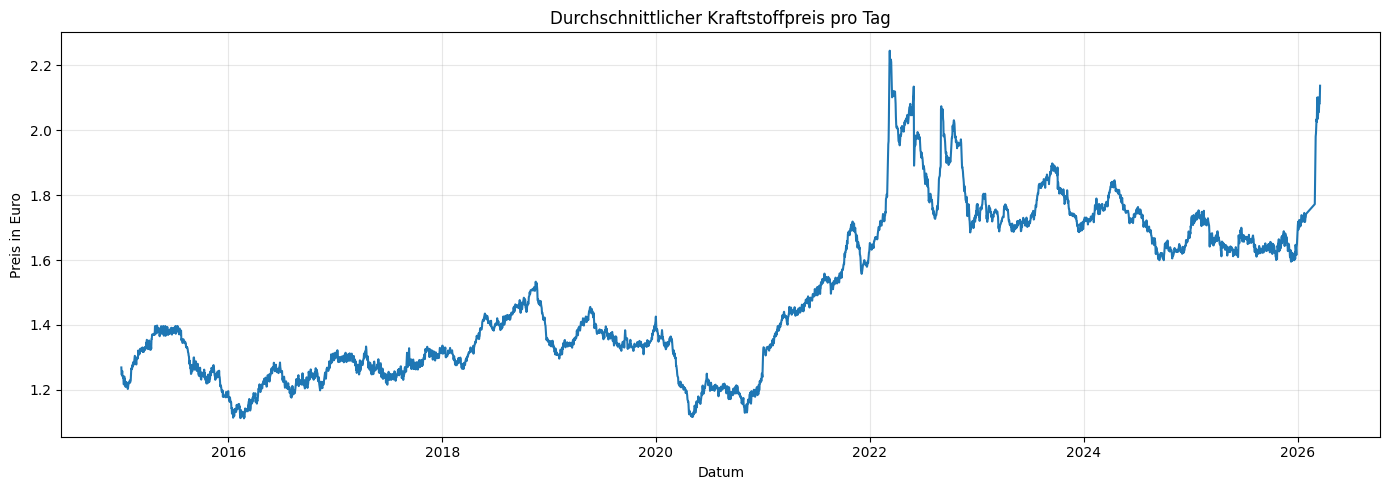

In [158]:
import matplotlib.pyplot as plt

# Datum sicherstellen
df_preis_long_db["date"] = pd.to_datetime(df_preis_long_db["date"])

# Durchschnitt pro Tag
preis_pro_tag = (
    df_preis_long
    .groupby(df_preis_long_db["date"].dt.date)["preis"]
    .mean()
)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(preis_pro_tag.index, preis_pro_tag.values)
plt.title("Durchschnittlicher Kraftstoffpreis pro Tag")
plt.xlabel("Datum")
plt.ylabel("Preis in Euro")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

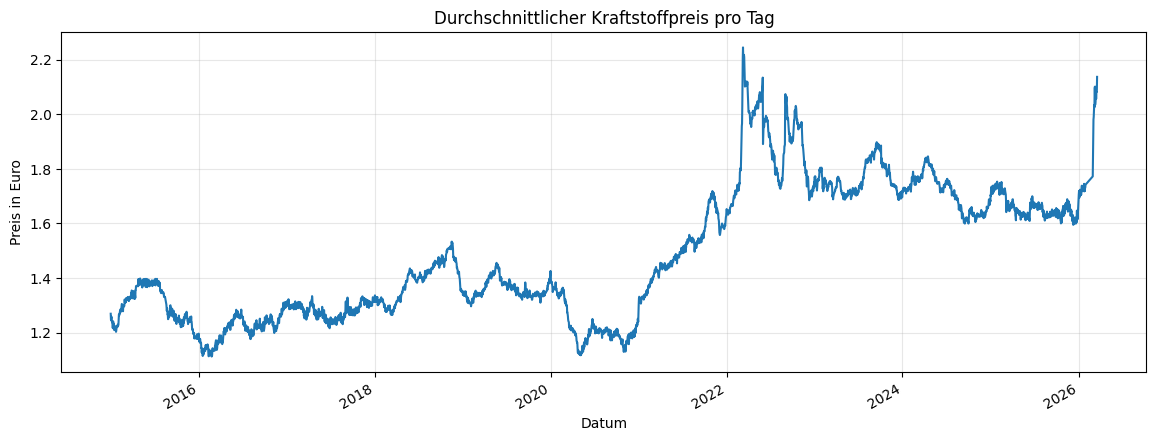

In [159]:

import matplotlib.pyplot as plt

# Durchschnittlicher Preis pro Tag
preis_pro_tag = df_preis_long_db.groupby(df_preis_long_db["date"].dt.floor("D"))["preis"].mean()

plt.figure(figsize=(14, 5))
preis_pro_tag.plot()
plt.title("Durchschnittlicher Kraftstoffpreis pro Tag")
plt.xlabel("Datum")
plt.ylabel("Preis in Euro")
plt.grid(True, alpha=0.3)
plt.show()


### 2. Beste Tankzeit nach Uhrzeit


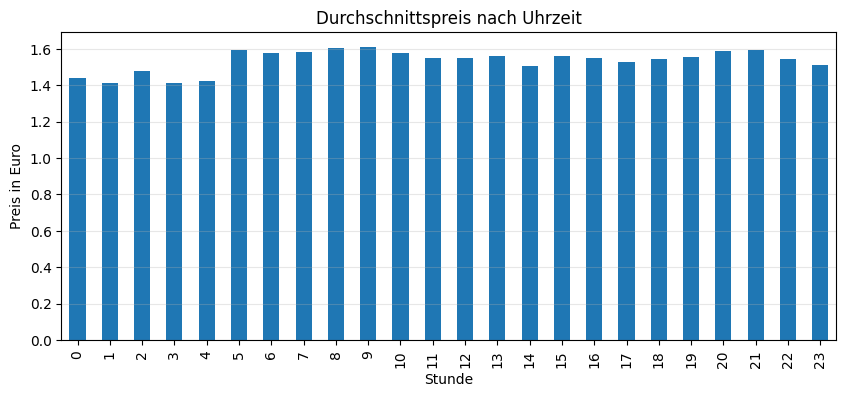

Günstigste Stunde: 3


In [160]:

# Falls stunde noch nicht existiert, hier aus date ableiten
if "stunde" not in df_preis_long_db.columns:
    df_preis_long_db["stunde"] = pd.to_datetime(df_preis_long_db["date"]).dt.hour

preis_pro_stunde = df_preis_long_db.groupby("stunde")["preis"].mean()

plt.figure(figsize=(10, 4))
preis_pro_stunde.plot(kind="bar")
plt.title("Durchschnittspreis nach Uhrzeit")
plt.xlabel("Stunde")
plt.ylabel("Preis in Euro")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

print("Günstigste Stunde:", preis_pro_stunde.idxmin())


### 3. Preis nach Wochentag


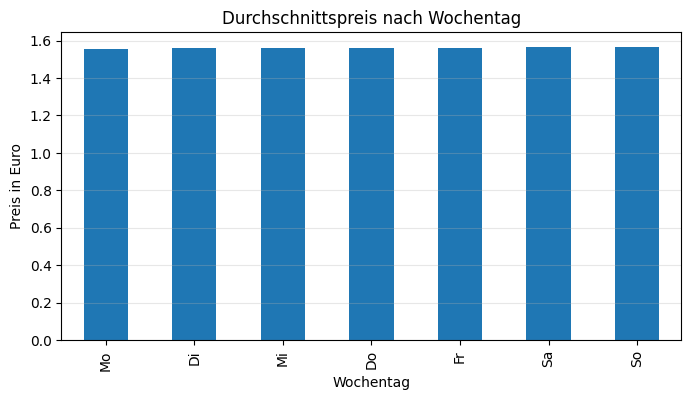

kraftstoff
diesel    1.482069
e10       1.578370
e5        1.624449
Name: preis, dtype: float32

In [161]:

if "wochentag" not in df_preis_long_db.columns:
    df_preis_long_db["wochentag"] = pd.to_datetime(df_preis_long_db["date"]).dt.weekday

wochentag_namen = {0: "Mo", 1: "Di", 2: "Mi", 3: "Do", 4: "Fr", 5: "Sa", 6: "So"}
preis_pro_wochentag = df_preis_long_db.groupby("wochentag")["preis"].mean().rename(index=wochentag_namen)

plt.figure(figsize=(8, 4))
preis_pro_wochentag.plot(kind="bar")
plt.title("Durchschnittspreis nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Preis in Euro")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Kraftstoffvergleich direkt mit ausgeben
kraftstoffvergleich = df_preis_long_db.groupby("kraftstoff")["preis"].mean().sort_values()
display(kraftstoffvergleich)


### 4. Korrelationen wichtiger Einflussfaktoren


In [162]:

# Nur numerische Spalten für Korrelation verwenden
num_cols = df_ml.select_dtypes(include=["number", "bool"]).copy()

# Bool-Spalten für Korrelation in int umwandeln
for col in num_cols.select_dtypes(include=["bool"]).columns:
    num_cols[col] = num_cols[col].astype(int)

korrelationen = num_cols.corr(numeric_only=True)["preis"].sort_values(ascending=False)
display(korrelationen)


preis                   1.000000
brent_usd               0.825872
co2_benzin_ct_brutto    0.695200
co2_diesel_ct_brutto    0.695199
co2_preis_eur_t         0.695198
co2_diesel_ct_netto     0.695198
co2_benzin_ct_netto     0.695198
ist_niedrigwasser       0.211067
ist_tankrabatt          0.189044
ist_schaetzwert         0.165390
sonnenstunden           0.056710
temp_min                0.014621
niederschlag_mm         0.004991
temp_avg               -0.019902
temp_max               -0.032248
energiesteuer_benzin   -0.197030
energiesteuer_diesel   -0.197030
ist_lockdown           -0.231951
eur_usd                -0.438133
Name: preis, dtype: float64

### 5. Einfache Visualisierungen der Einflussfaktoren


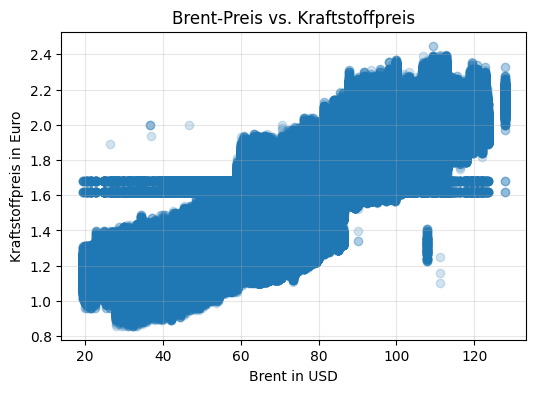

In [163]:

# Ölpreis vs. Kraftstoffpreis
plt.figure(figsize=(6, 4))
plt.scatter(df_ml["brent_usd"], df_ml["preis"], alpha=0.2)
plt.title("Brent-Preis vs. Kraftstoffpreis")
plt.xlabel("Brent in USD")
plt.ylabel("Kraftstoffpreis in Euro")
plt.grid(True, alpha=0.3)
plt.show()


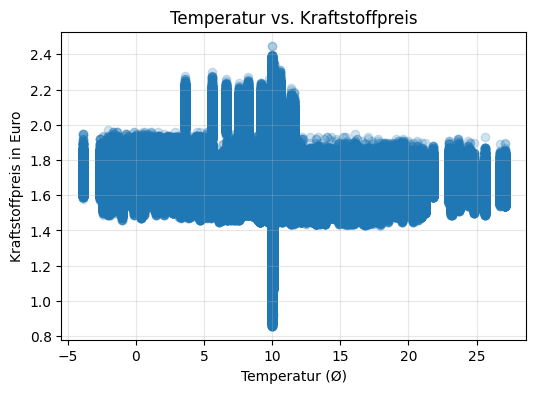

In [164]:

# Temperatur vs. Kraftstoffpreis
plt.figure(figsize=(6, 4))
plt.scatter(df_ml["temp_avg"], df_ml["preis"], alpha=0.2)
plt.title("Temperatur vs. Kraftstoffpreis")
plt.xlabel("Temperatur (Ø)")
plt.ylabel("Kraftstoffpreis in Euro")
plt.grid(True, alpha=0.3)
plt.show()


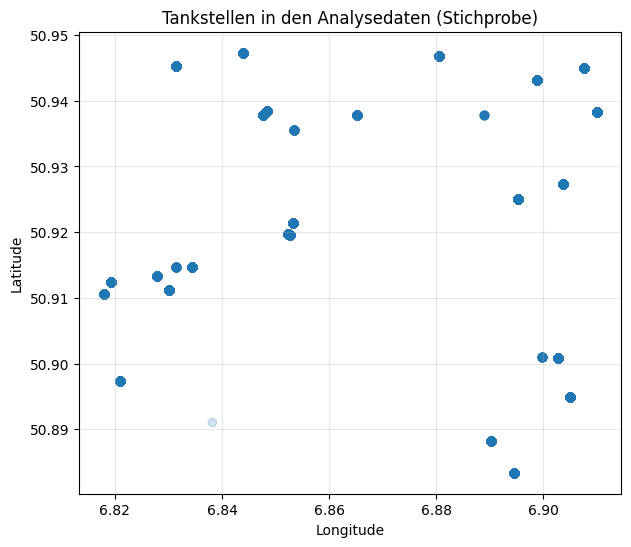

In [165]:

# Karte / räumlicher Überblick der Stationen
if {"longitude", "latitude", "preis"}.issubset(df_analysis.columns):
    sample_map = df_analysis[["longitude", "latitude", "preis"]].dropna().sample(
        min(5000, len(df_analysis.dropna(subset=["longitude", "latitude", "preis"]))),
        random_state=42
    )

    plt.figure(figsize=(7, 6))
    plt.scatter(sample_map["longitude"], sample_map["latitude"], alpha=0.2)
    plt.title("Tankstellen in den Analysedaten (Stichprobe)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Longitude/Latitude nicht verfügbar – Kartenplot übersprungen.")


In [166]:

# Optional: Daten für spätere Modellierung speichern
# Vorteil: Ab hier kann dein ML-Teil direkt auf einem sauberen Master-Dataset aufsetzen.

df_ml.to_parquet("ml_master_dataset.parquet", index=False)
df_analysis.to_parquet("analysis_dataset.parquet", index=False)

print("Dateien gespeichert: ml_master_dataset.parquet, analysis_dataset.parquet")


Dateien gespeichert: ml_master_dataset.parquet, analysis_dataset.parquet


### 6. Nächster sinnvoller Schritt für ML

Für das Modell solltest du als Nächstes `train_test_split` zeitbasiert machen und keine zufällige Mischung über die Zeit verwenden.


Die vorherigen Fehler kamen hauptsächlich daher, dass in der Analyse noch `df_preis` statt `df_preis_long` verwendet wurde und einige Join-Tabellen noch `period` statt `date` hatten.
